<center><p float="center">
  <img src="https://upload.wikimedia.org/wikipedia/commons/e/e9/4_RGB_McCombs_School_Brand_Branded.png" width="300" height="100"/>
  <img src="https://mma.prnewswire.com/media/1458111/Great_Learning_Logo.jpg?p=facebook" width="200" height="100"/>
</p></center>

<h1><center><font size=10>Data Science and Business Analytics</center></font></h1>
<h1><center>Supervised Learning Classification: Project - Inn Hotels Booking Cancelations</center></h1>

<center><img src="C:\Users\josep\Pictures\Hotel_cancel4.png" width="720"></center>

<center><font size=6> By Joseph Anyanwu </font></center>

# INN Hotels Project

## Context

A significant number of hotel bookings are called-off due to cancellations or no-shows. The typical reasons for cancellations include change of plans, scheduling conflicts, etc. This is often made easier by the option to do so free of charge or preferably at a low cost which is beneficial to hotel guests but it is a less desirable and possibly revenue-diminishing factor for hotels to deal with. Such losses are particularly high on last-minute cancellations.

The new technologies involving online booking channels have dramatically changed customers’ booking possibilities and behavior. This adds a further dimension to the challenge of how hotels handle cancellations, which are no longer limited to traditional booking and guest characteristics.

The cancellation of bookings impact a hotel on various fronts:
* Loss of resources (revenue) when the hotel cannot resell the room.
* Additional costs of distribution channels by increasing commissions or paying for publicity to help sell these rooms.
* Lowering prices last minute, so the hotel can resell a room, resulting in reducing the profit margin.
* Human resources to make arrangements for the guests.

## Objective
The increasing number of cancellations calls for a Machine Learning based solution that can help in predicting which booking is likely to be canceled. INN Hotels Group has a chain of hotels in Portugal, they are facing problems with the high number of booking cancellations and have reached out to your firm for data-driven solutions. You as a data scientist have to analyze the data provided to find which factors have a high influence on booking cancellations, build a predictive model that can predict which booking is going to be canceled in advance, and help in formulating profitable policies for cancellations and refunds.

## Data Description
The data contains the different attributes of customers' booking details. The detailed data dictionary is given below.


**Data Dictionary**

* Booking_ID: unique identifier of each booking
* no_of_adults: Number of adults
* no_of_children: Number of Children
* no_of_weekend_nights: Number of weekend nights (Saturday or Sunday) the guest stayed or booked to stay at the hotel
* no_of_week_nights: Number of week nights (Monday to Friday) the guest stayed or booked to stay at the hotel
* type_of_meal_plan: Type of meal plan booked by the customer:
    * Not Selected – No meal plan selected
    * Meal Plan 1 – Breakfast
    * Meal Plan 2 – Half board (breakfast and one other meal)
    * Meal Plan 3 – Full board (breakfast, lunch, and dinner)
* required_car_parking_space: Does the customer require a car parking space? (0 - No, 1- Yes)
* room_type_reserved: Type of room reserved by the customer. The values are ciphered (encoded) by INN Hotels.
* lead_time: Number of days between the date of booking and the arrival date
* arrival_year: Year of arrival date
* arrival_month: Month of arrival date
* arrival_date: Date of the month
* market_segment_type: Market segment designation.
* repeated_guest: Is the customer a repeated guest? (0 - No, 1- Yes)
* no_of_previous_cancellations: Number of previous bookings that were canceled by the customer prior to the current booking
* no_of_previous_bookings_not_canceled: Number of previous bookings not canceled by the customer prior to the current booking
* avg_price_per_room: Average price per day of the reservation; prices of the rooms are dynamic. (in euros)
* no_of_special_requests: Total number of special requests made by the customer (e.g. high floor, view from the room, etc)
* booking_status: Flag indicating if the booking was canceled or not.

## Importing necessary libraries and data

In [1]:
# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Removes the limit for the number of displayed columns
pd.set_option("display.max_columns", None)
# Sets the limit for the number of displayed rows
pd.set_option("display.max_rows", 200)
# setting the precision of floating numbers to 5 decimal points
pd.set_option("display.float_format", lambda x: "%.5f" % x)

# Library to split data
from sklearn.model_selection import train_test_split

# To build model for prediction
import statsmodels.stats.api as sms
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from statsmodels.tools.tools import add_constant
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn import tree

# To tune different models
from sklearn.model_selection import GridSearchCV


# To get diferent metric scores
from sklearn.metrics import (
    f1_score,
    accuracy_score,
    recall_score,
    precision_score,
    confusion_matrix,
    roc_auc_score,
    precision_recall_curve,
    roc_curve,
    make_scorer,
)

import warnings
warnings.filterwarnings("ignore")

from statsmodels.tools.sm_exceptions import ConvergenceWarning
warnings.simplefilter("ignore", ConvergenceWarning)

## Loading data

In [3]:
filepath = "Downloads/INNHotelsGroup.csv"
inn_main = pd.read_csv(filepath)

print(f"✅ File uploaded and read successfully!")

✅ File uploaded and read successfully!


In [5]:
# copying data to another variable to avoid any changes to original data
inn = inn_main.copy()

### View the first and last 5 rows of the dataset.

In [7]:
inn.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00000,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68000,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00000,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00000,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50000,0,Canceled


In [9]:
inn.tail()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
36270,INN36271,3,0,2,6,Meal Plan 1,0,Room_Type 4,85,2018,8,3,Online,0,0,0,167.80000,1,Not_Canceled
36271,INN36272,2,0,1,3,Meal Plan 1,0,Room_Type 1,228,2018,10,17,Online,0,0,0,90.95000,2,Canceled
36272,INN36273,2,0,2,6,Meal Plan 1,0,Room_Type 1,148,2018,7,1,Online,0,0,0,98.39000,2,Not_Canceled
36273,INN36274,2,0,0,3,Not Selected,0,Room_Type 1,63,2018,4,21,Online,0,0,0,94.50000,0,Canceled
36274,INN36275,2,0,1,2,Meal Plan 1,0,Room_Type 1,207,2018,12,30,Offline,0,0,0,161.67000,0,Not_Canceled


-  The dataset contains information about different types of booking reservations.

### Understand the shape of the dataset.

In [11]:
inn.shape

(36275, 19)

* The dataset has 36275 rows and 19 columns

### Check the data types and statistics of the columns for the dataset.

In [13]:
inn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_date   

* Dependent variable is the `booking_status` which is of categorical type.
* `Booking_ID`, `type_of_meal_plan`, `room_type_reserved`, and `market_segment_type` are of categorical type while other variables are numerical (integer aand float types).
* There are no missing values in the dataset.

In [15]:
inn.describe().T

,count,mean,std,min,25%,50%,75%,max
no_of_adults,36275.00000,1.84496,0.51871,0.00000,2.00000,2.00000,2.00000,4.00000
no_of_children,36275.00000,0.10528,0.40265,0.00000,0.00000,0.00000,0.00000,10.00000
no_of_weekend_nights,36275.00000,0.81072,0.87064,0.00000,0.00000,1.00000,2.00000,7.00000
no_of_week_nights,36275.00000,2.20430,1.41090,0.00000,1.00000,2.00000,3.00000,17.00000
required_car_parking_space,36275.00000,0.03099,0.17328,0.00000,0.00000,0.00000,0.00000,1.00000
lead_time,36275.00000,85.23256,85.93082,0.00000,17.00000,57.00000,126.00000,443.00000
arrival_year,36275.00000,2017.82043,0.38384,2017.00000,2018.00000,2018.00000,2018.00000,2018.00000
arrival_month,36275.00000,7.42365,3.06989,1.00000,5.00000,8.00000,10.00000,12.00000
arrival_date,36275.00000,15.59700,8.74045,1.00000,8.00000,16.00000,23.00000,31.00000
repeated_guest,36275.00000,0.02564,0.15805,0.00000,0.00000,0.00000,0.00000,1.00000


- The maximum `no_of_adults` and `no_of_children` are 4 and 10 respectively.
- The `arrival_year` was between 2017 and 2018 with arrival_date between the first and last day of respective months of the year.
- The `maximum lead_time` observed was 443 days
- The `no_of_week_nights` is higher than the `no_of_weekend_nights`.
- The `no_of_previous_bookings_not_canceled` is very much higher than `no_of_previous_cancellations`.
- The maximum `avg_price_per_room` is €540.00 while it averages at €103.42.

##Check for missing values and duplicates

In [17]:
# checking for duplicates
inn.duplicated().sum()

0

There are no duplicates in the dataset

In [19]:
# checking for null values
print(inn.isnull().sum())
print("--" * 50)
print(inn.isna().sum())  # checking for NAN values

Booking_ID                              0
no_of_adults                            0
no_of_children                          0
no_of_weekend_nights                    0
no_of_week_nights                       0
type_of_meal_plan                       0
required_car_parking_space              0
room_type_reserved                      0
lead_time                               0
arrival_year                            0
arrival_month                           0
arrival_date                            0
market_segment_type                     0
repeated_guest                          0
no_of_previous_cancellations            0
no_of_previous_bookings_not_canceled    0
avg_price_per_room                      0
no_of_special_requests                  0
booking_status                          0
dtype: int64
----------------------------------------------------------------------------------------------------
Booking_ID                              0
no_of_adults                            0
no_o

- There are no duplicates, no null values, no NAN, and no missing data in the dataset

### Dropping the columns with all unique values

In [21]:
inn.Booking_ID.nunique()

36275

The Booking_ID column contains only unique values, so we drop it because it won't have effect on the data model

In [24]:
# dropping the Booking_ID column

inn.drop(columns=["Booking_ID"], inplace=True) # the DataFrame would be modified directly, and there would be no need to reassign the result to data

#inn = data.drop(["Booking_ID"], axis=1) # specifying to drop a column (axis=1); for row (axis=0)

## Exploratory Data Analysis (EDA)


**Let us check which of these variables are statistically significant.**

- The Chi-Square test is a statistical method to determine if two categorical variables have a significant correlation between them.
  
  - **Null Hypothesis -** There is no association between the two variables.      
  - **Alternate Hypothesis -** There is an association between two variables.

In [27]:
import scipy.stats as stats
crosstab = pd.crosstab(
    inn["no_of_adults"], inn["no_of_children"]
)  # Contingency table of no_of_adults and no_of_children attributes

Ho = "no_of_adults has no effect on no_of_children"  # Stating the Null Hypothesis
Ha = "no_of_adults has an effect on no_of_children"  # Stating the Alternate Hypothesis

chi, p_value, dof, expected = stats.chi2_contingency(crosstab)

if p_value < 0.05:  # Setting our significance level at 5%
    print(f"{Ha} as the p_value ({p_value.round(3)}) < 0.05")
else:
    print(f"{Ho} as the p_value ({p_value.round(3)}) > 0.05")

no_of_adults has an effect on no_of_children as the p_value (0.0) < 0.05


In [29]:
#import scipy.stats as stats
crosstab = pd.crosstab(
    inn["arrival_year"], inn["arrival_month"]
)  # Contingency table of arrival_year and arrival_month attributes

Ho = "arrival_year has no effect on arrival_month"  # Stating the Null Hypothesis
Ha = "arrival_year has an effect on arrival_month"  # Stating the Alternate Hypothesis

chi, p_value, dof, expected = stats.chi2_contingency(crosstab)

if p_value < 0.05:  # Setting our significance level at 5%
    print(f"{Ha} as the p_value ({p_value.round(3)}) < 0.05")
else:
    print(f"{Ho} as the p_value ({p_value.round(3)}) > 0.05")

arrival_year has an effect on arrival_month as the p_value (0.0) < 0.05


- There is a correlation between no_of_adults and no_of_children
- There is a correlation between arrival_year and arrival_month
- It is possible to high multicolinearity amongst the pairs

**Next we define functions to carry out further exploratory data analysis**

In [31]:
# function to create histogram and boxplot
def histogram_boxplot(data, feature, figsize=(10, 5), kde=False, bins=None):
    """
    Boxplot and histogram combined

    data: dataframe
    feature: dataframe column
    figsize: size of figure (default (10,5))
    kde: whether to show the density curve (default False)
    bins: number of bins for histogram (default None)
    """
    f2, (ax_box2, ax_hist2) = plt.subplots(
        nrows=2,  # Number of rows of the subplot grid= 2
        sharex=True,  # x-axis will be shared among all subplots
        gridspec_kw={"height_ratios": (0.25, 0.75)},
        figsize=figsize,
    )  # creating the 2 subplots
    sns.boxplot(
        data=data, x=feature, ax=ax_box2, showmeans=True, color="violet"
    )  # boxplot will be created and a triangle will indicate the mean value of the column
    sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2, bins=bins
    ) if bins else sns.histplot(
        data=data, x=feature, kde=kde, ax=ax_hist2
    )  # For histogram
    ax_hist2.axvline(
        data[feature].mean(), color="green", linestyle="--"
    )  # Add mean to the histogram
    ax_hist2.axvline(
        data[feature].median(), color="black", linestyle="-"
    )  # Add median to the histogram

In [33]:
# function to create labeled barplots

def labeled_barplot(data, feature, perc=False, n=None, title=None, xlabel=None, ylabel=None):
    """
    Barplot with percentage at the top

    data: dataframe
    feature: dataframe column
    perc: whether to display percentages instead of count (default is False)
    n: displays the top n category levels (default is None, i.e., display all levels)
    """

    total = len(data[feature])  # length of the column
    count = data[feature].nunique()
    if n is None:
        plt.figure(figsize=(count + 2, 6))
    else:
        plt.figure(figsize=(n + 2, 6))

    plt.xticks(rotation=90, fontsize=15)
    ax = sns.countplot(
        data=data,
        x=feature,
        hue=feature,
        palette="Paired",
        order=data[feature].value_counts().index[:n],
    )

    for p in ax.patches:
      if p.get_height() > 0:  # Exclude zero-height bars
        if perc:
            label = "{:.1f}%".format(100 * p.get_height() / total)
        else:
            label = p.get_height()

        x = p.get_x() + p.get_width() / 2
        y = p.get_height()

        ax.annotate(
            label,
            (x, y),
            ha="center",
            va="bottom",  # Ensures label is placed above the bar
            size=10,
            xytext=(0, 5),
            textcoords="offset points",
        )

    if title:  # Add title if provided
        plt.title(title, fontsize=14)
    if xlabel:  # Add xlabel if provided
        plt.xlabel(xlabel, fontsize=12)
    if ylabel:  # Add ylabel if provided
        plt.ylabel(ylabel, fontsize=12)

    plt.show()  # show the plot

In [35]:
def stacked_barplot(data, predictor, target, title=None, xlabel=None, ylabel=None):
    """
    Print the category counts and plot a stacked bar chart

    data: dataframe
    predictor: independent variable
    target: target variable
    """
    count = data[predictor].nunique()
    sorter = data[target].value_counts().index[-1]
    tab1 = pd.crosstab(data[predictor], data[target], margins=True).sort_values(
        by=sorter, ascending=False
    )
    print(tab1)
    print("-" * 120)
    tab = pd.crosstab(data[predictor], data[target], normalize="index").sort_values(
        by=sorter, ascending=False
    )
    tab.plot(kind="bar", stacked=True, figsize=(count + 5, 5))
    plt.legend(
        loc="lower left", frameon=False,
    )
    plt.legend(loc="upper left", bbox_to_anchor=(1, 1))


    if xlabel:  # Add xlabel if provided
        plt.xlabel(xlabel, fontsize=12)
    if ylabel:  # Add ylabel if provided
        plt.ylabel(ylabel, fontsize=12)
    if title:  # Add title if provided
        plt.title(title, fontsize=14)

    plt.show()

**Leading Questions**:
1. What are the busiest months in the hotel?
2. Which market segment do most of the guests come from?
3. Hotel rates are dynamic and change according to demand and customer demographics. What are the differences in room prices in different market segments?
4. What percentage of bookings are canceled?
5. Repeating guests are the guests who stay in the hotel often and are important to brand equity. What percentage of repeating guests cancel?
6. Many guests have special requirements when booking a hotel room. Do these requirements affect booking cancellation?

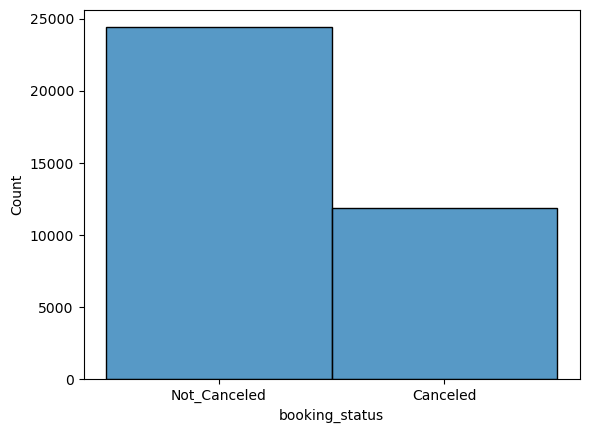

In [51]:
# Distribution of the booking_status
sns.histplot(data=inn, x='booking_status');

The booking status is unevenly distributed between canceled and not-canceled

***Question 1: What are the busiest months in the hotel?***

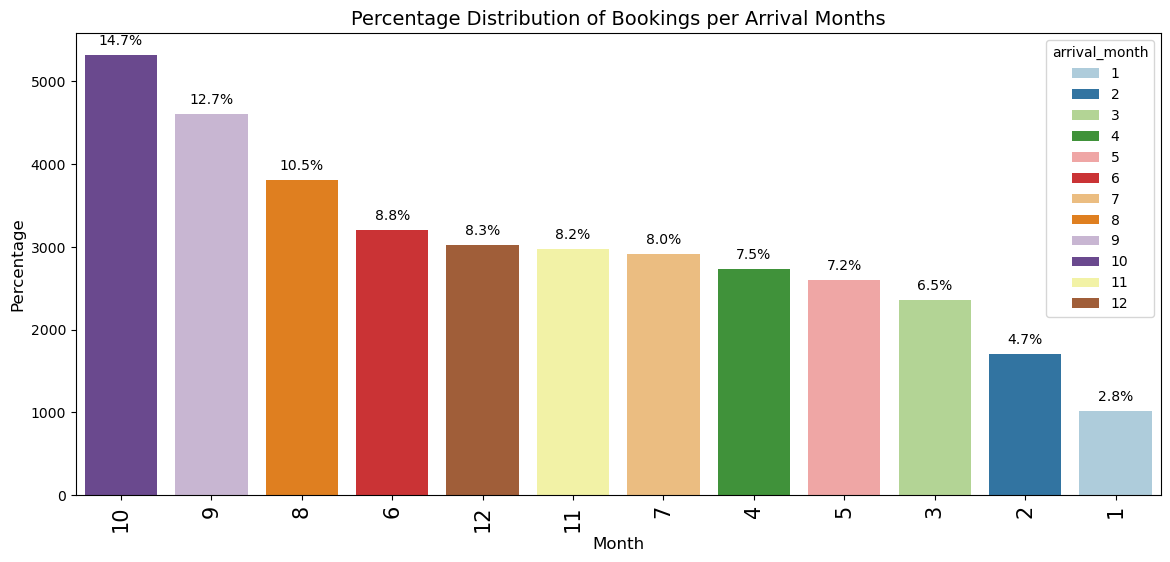

arrival_month
10    5317
9     4611
8     3813
6     3203
12    3021
Name: count, dtype: int64


In [54]:
# Count the number of bookings per month
busiest_months = inn['arrival_month'].value_counts().sort_index()

# Plot the results

labeled_barplot(inn, "arrival_month", perc=True, title = 'Percentage Distribution of Bookings per Arrival Months', xlabel="Month", ylabel="Percentage")

# Display busiest months in descending order
print(busiest_months.sort_values(ascending=False).head())

The top 3 busiest months in the hotel are October, September and August with percentage visits of 14.7%, 12.7% and 10.5% of the total visits respectively.

***Question 2: Which market segment do most of the guests come from?***

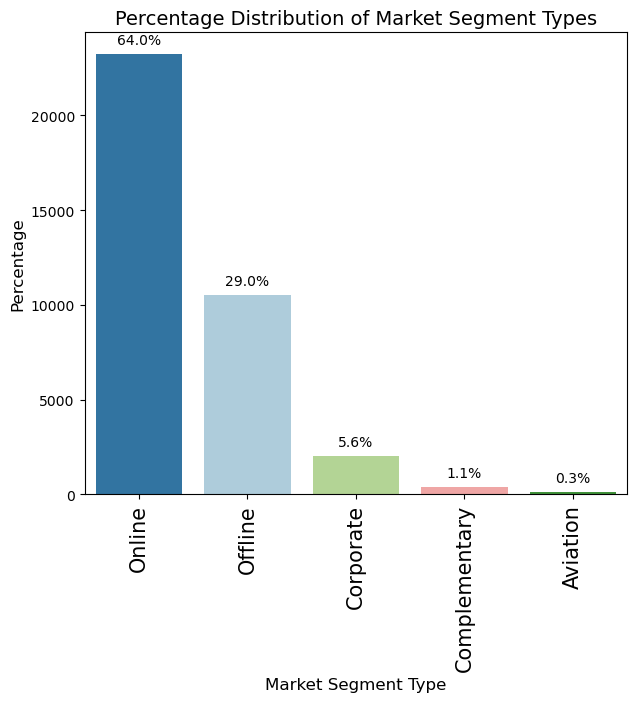

----------------------------------------------------------------------------------------------------


,Market Segment Type,Total Visits
0,Online,23214


In [56]:
# Which market segment do most of the guests come from?

labeled_barplot(inn, "market_segment_type", perc=True, title= 'Percentage Distribution of Market Segment Types', xlabel="Market Segment Type", ylabel="Percentage")

print("--"*50)
# Select the top market segment type
mkt_type = pd.DataFrame(inn.market_segment_type.value_counts())
mkt_type.reset_index(inplace=True)
mkt_type.columns = ['Market Segment Type', 'Total Visits']
mkt_type.head(1)


With total visits of 23,214 which makes 64% of the total market segments, Online is the segment through which most guests come from.

***Question 3: What are the differences in room prices in different market segments?***

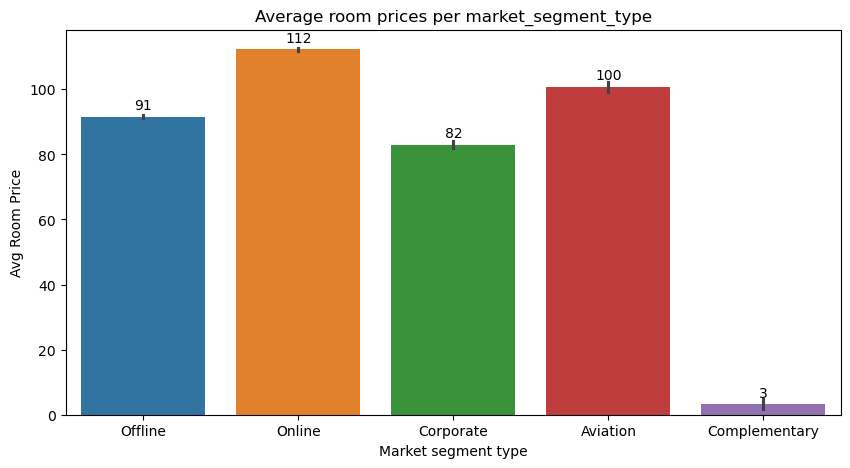

----------------------------------------------------------------------------------------------------


,market_segment_type,avg_price_per_room
0,Aviation,100.70400
1,Complementary,3.14176
2,Corporate,82.91174
3,Offline,91.63268
4,Online,112.25685


In [58]:
# What are the differences in room prices in different market segments?

plt.figure(figsize=(10, 5))
plt.title('Average room prices per market_segment_type')
plt.xlabel('Market segment type')
plt.ylabel('Avg Room Price')
ax = sns.barplot(x="market_segment_type", y="avg_price_per_room", data=inn, hue='market_segment_type')
#sns.barplot(x="market_segment_type", y="avg_price_per_room", data=barplot_data, hue='market_segment_type');

# Add labels on the bars
for container in ax.containers:
    ax.bar_label(container, fmt='%d', label_type='edge', fontsize=10, padding=3)

plt.show();
print("--"*50)
barplot_data = inn.groupby("market_segment_type").agg({"avg_price_per_room": "mean"}).reset_index()
barplot_data

- At 112.00 euros, Online segment has the highest average room price of all the market segment indicating strong demand or premium pricing for the convenience of online bookings.
- With an average price of 100.70 euros, the Aviation segment likely includes bookings tied to airline partnerships, corporate travel, or urgent travel needs.
- The  Moderately Priced Offline segment has an average price of 91.63 euros, slightly lower than online bookings, which could be due to negotiated rates at physical locations or direct bookings.

***Question 4: What percentage of bookings are canceled?***

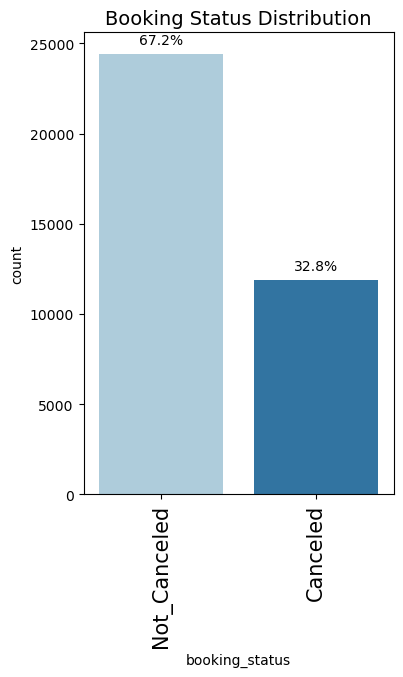

Percentage of canceled bookings: 32.76%


In [60]:
# What percentage of bookings are canceled?
labeled_barplot(inn, "booking_status", perc=True, title='Booking Status Distribution')

no_of_canceled_bookings = inn[inn["booking_status"] == "Canceled"].shape[0]
total_bookings = inn.shape[0]
percentage_canceled_bookings = (no_of_canceled_bookings / total_bookings) * 100

print(f"Percentage of canceled bookings: {percentage_canceled_bookings:.2f}%")

Of the total bookings made, 32.8% of it were canceled.

***Question 5: What percentage of repeating guests cancel?***

In [62]:
# Percentage of repeating guests cancelling?
inn.groupby("repeated_guest").agg({"booking_status": "value_counts"})

booking_status
repeated_guest booking_status                
0              Not_Canceled             23476
               Canceled                 11869
1              Not_Canceled               914
               Canceled                    16

booking_status  Canceled  Not_Canceled    All
repeated_guest                               
All                11885         24390  36275
0                  11869         23476  35345
1                     16           914    930
------------------------------------------------------------------------------------------------------------------------


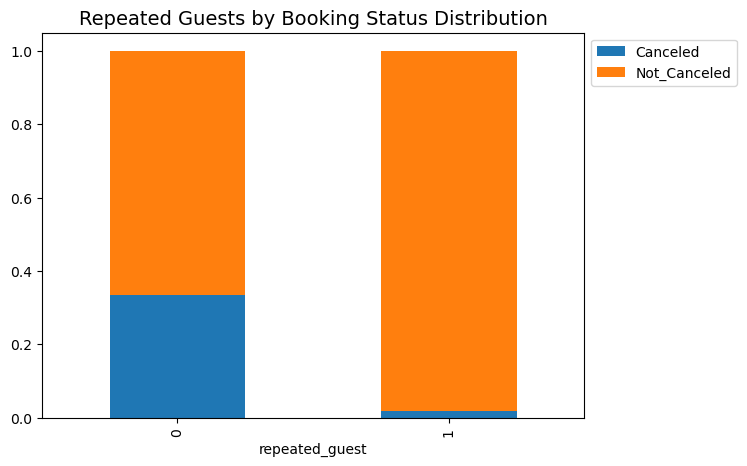

Percentage of repeated guests canceling: 1.72%


In [64]:
# Percentage of repeating guests cancelling?
#inn.groupby("repeated_guest").agg({"booking_status": "value_counts"})

no_of_repeated_guests_canceled_bookings = inn[(inn["booking_status"] == "Canceled") & (inn["repeated_guest"] == 1)].shape[0]
total_repeated_guests = inn[inn["repeated_guest"] == 1].shape[0]
percentage_repeated_guests_canceled = (no_of_repeated_guests_canceled_bookings / total_repeated_guests) * 100


stacked_barplot(inn, "repeated_guest", "booking_status", title='Repeated Guests by Booking Status Distribution')

print(f"Percentage of repeated guests canceling: {percentage_repeated_guests_canceled:.2f}%")

The percentage of repeated guests canceling is 1.72%

***Question 6: Many guests have special requirements when booking a hotel room. Do these requirements affect booking cancellation?***

booking_status          Canceled  Not_Canceled    All
no_of_special_requests                               
All                        11885         24390  36275
0                           8545         11232  19777
1                           2703          8670  11373
2                            637          3727   4364
3                              0           675    675
4                              0            78     78
5                              0             8      8
------------------------------------------------------------------------------------------------------------------------


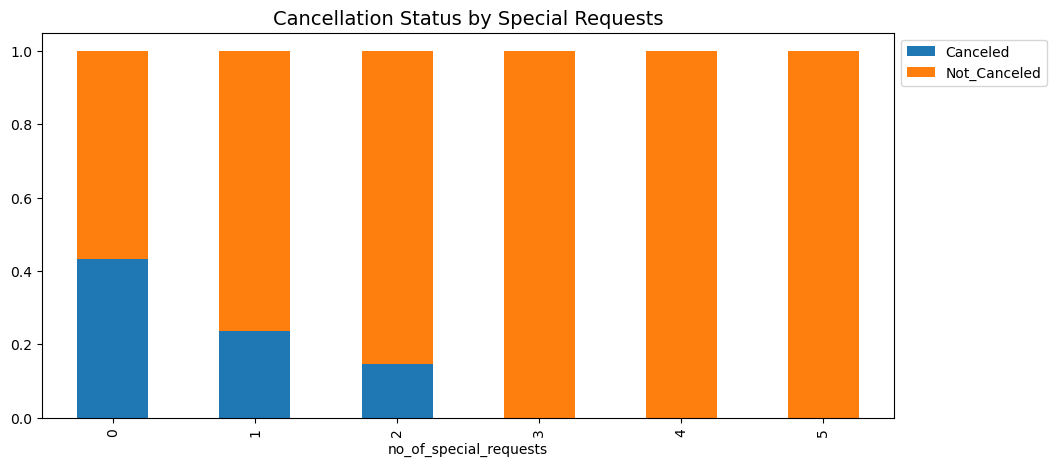

In [66]:
# How does requirements affect booking cancellation?
#inn.groupby("no_of_special_requests").agg({"booking_status": "value_counts"}).unstack()

stacked_barplot(inn, "no_of_special_requests", "booking_status", title = 'Cancellation Status by Special Requests')

- **Higher Cancellation Rate with No Special Requests**: 8,545 out of 19,777 (~43%) of guests with 0 special requests canceled their bookings.The proportion of canceled bookings (blue bars) is highest when the number of special requests is zero. This suggests that guests who make no special requests may have a higher tendency to cancel.


- **Lower Cancellation Rate with More Special Requests**: As the number of special requests increases, the number of cancellations drops to zero from 3 special requests onward.

- This suggests that guests who make special requests (e.g., room preferences, meal options) are likely more committed to their stay and less likely to cancel.

##Check for Outliers

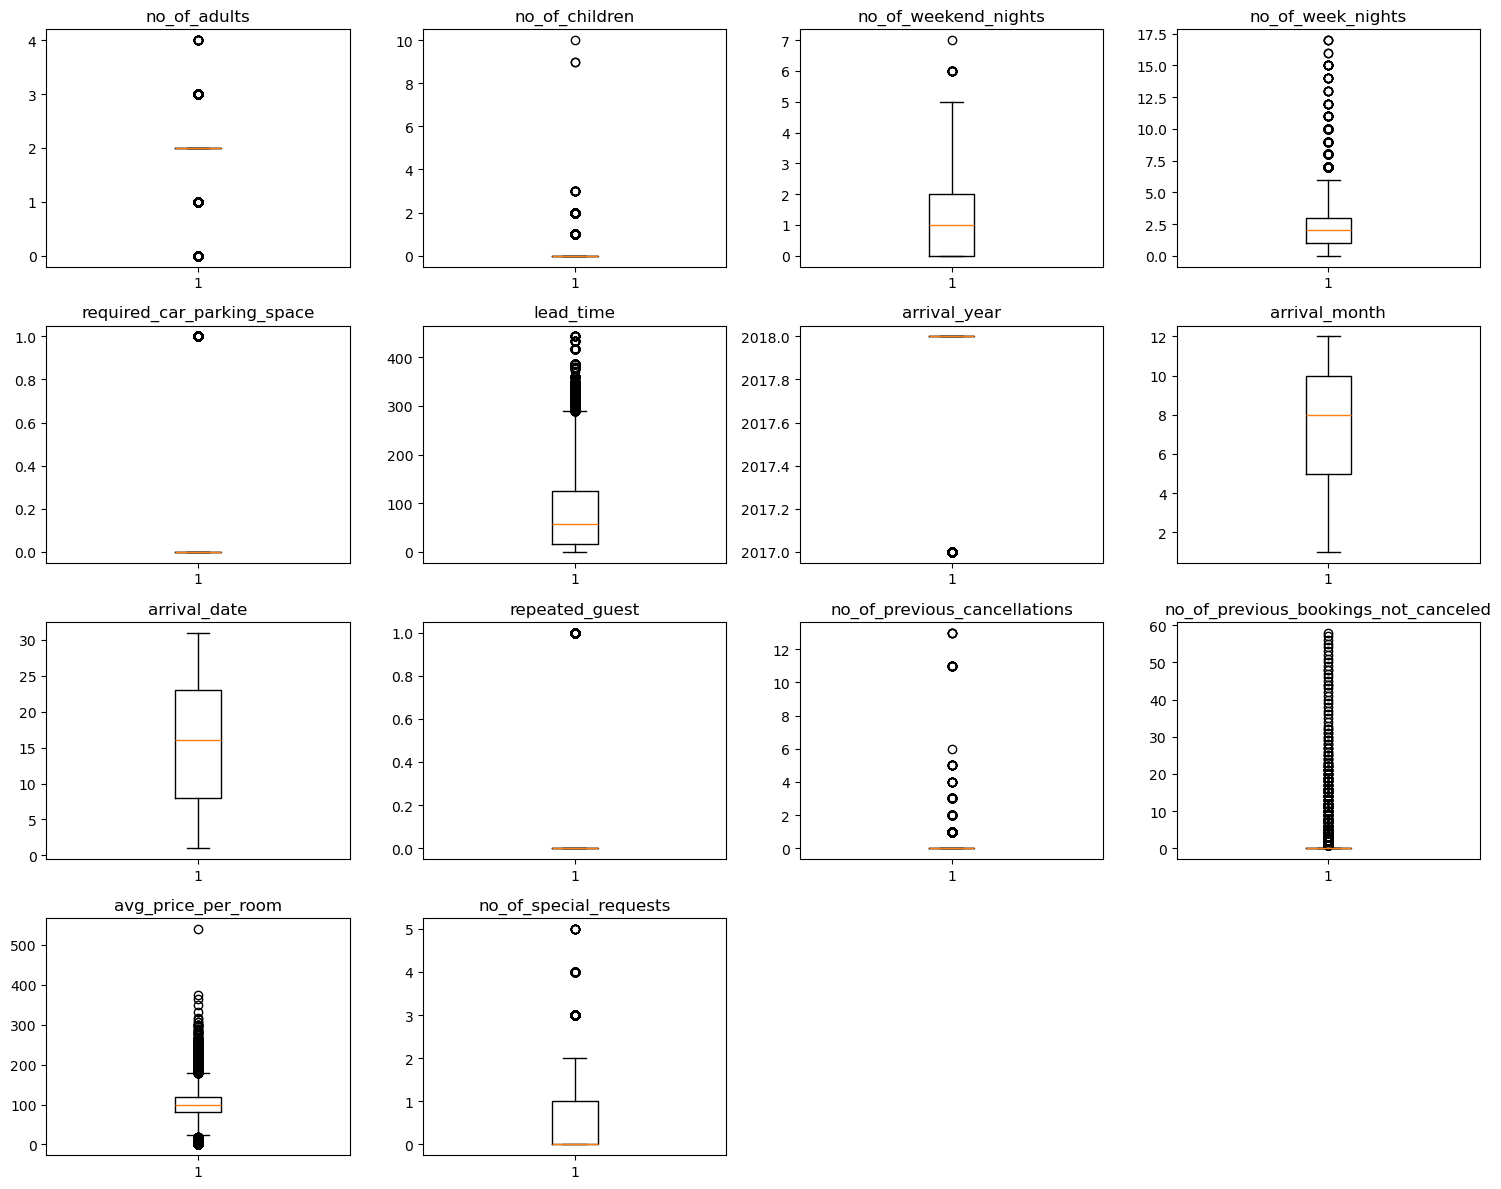

In [68]:
# outlier detection using boxplot
numeric_columns = inn.select_dtypes(include=np.number).columns.tolist()

plt.figure(figsize=(15, 12))

for i, variable in enumerate(numeric_columns):
    plt.subplot(4, 4, i + 1)
    plt.boxplot(inn[variable], whis=1.5)
    plt.tight_layout()
    plt.title(variable)

plt.show()

There are several columns with outliers


## Data Treatment and Featured Engineering

Now we proceed to converting text-based object data types in the DataFrame into a categorical data type as further treatment of the data

In [70]:
# create a copy to preserve data before featured
inn2 = inn.copy()
# inn = inn2.copy()

In [72]:
# identify and convert text-based object data types in the DataFrame into a categorical data type

for feature in inn.columns: # Loop through all columns in the dataframe
    if inn[feature].dtype == 'object': # Only apply for columns with categorical strings
        inn[feature] = pd.Categorical(inn[feature])# Replace strings with a categorical integer

We will also convert arrival_year, arrival_month and booking status

In [74]:
# Convert arrival year and month to categorical
inn['arrival_year'] = inn['arrival_year'].astype('category')
inn['arrival_month'] = inn['arrival_month'].astype('category')
inn['arrival_date'] = inn['arrival_date'].astype('category')

- The arrival day (arrival_date) will be almost the same for all arrival months, but could have an impact on booking cancellations, especially if there are patterns linked to paydays, holidays, or travel trends at different times of the month.
- Instead of keeping the 31 days values, we will transform it into a more useful feature and meaningful categories to reduce noise.

In [76]:
# Create full_date column
from datetime import datetime
# Rename columns temporarily
def create_datetime(row):
    try:
        return datetime(row['arrival_year'], row['arrival_month'], row['arrival_date'])
    except ValueError:
        return pd.NaT  # Handle invalid dates gracefully

inn['full_date'] = inn.apply(create_datetime, axis=1)

inn['full_date'] = pd.to_datetime(inn['full_date'])

# Create day of week feature
inn['day_of_week'] = inn['full_date'].dt.day_name()
inn['day_of_week'] = inn['day_of_week'].astype('category')

# Create weekend/weekday feature
inn['is_weekend'] = (inn['full_date'].dt.dayofweek >= 5).astype(int)

# Create season feature
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Autumn'

inn['season'] = inn['full_date'].dt.month.apply(get_season)
inn['season'] = inn['season'].astype('category')

# Create days_since_start feature (if not using arrival_year as categorical)
start_date = datetime(2017, 1, 1) # since the arrival_year starts from 2017
inn['days_since_start'] = (inn['full_date'] - start_date).dt.days

In [78]:
# check and confirm change in data types
inn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 23 columns):
 #   Column                                Non-Null Count  Dtype         
---  ------                                --------------  -----         
 0   no_of_adults                          36275 non-null  int64         
 1   no_of_children                        36275 non-null  int64         
 2   no_of_weekend_nights                  36275 non-null  int64         
 3   no_of_week_nights                     36275 non-null  int64         
 4   type_of_meal_plan                     36275 non-null  category      
 5   required_car_parking_space            36275 non-null  int64         
 6   room_type_reserved                    36275 non-null  category      
 7   lead_time                             36275 non-null  int64         
 8   arrival_year                          36275 non-null  category      
 9   arrival_month                         36275 non-null  category      
 10

In [80]:
#check for null or missing values
#inn.loc[inn['days_since_start'] =='NAN']
print(inn.isnull().sum())
print("-"*50)
print(inn.isna().sum())

no_of_adults                             0
no_of_children                           0
no_of_weekend_nights                     0
no_of_week_nights                        0
type_of_meal_plan                        0
required_car_parking_space               0
room_type_reserved                       0
lead_time                                0
arrival_year                             0
arrival_month                            0
arrival_date                             0
market_segment_type                      0
repeated_guest                           0
no_of_previous_cancellations             0
no_of_previous_bookings_not_canceled     0
avg_price_per_room                       0
no_of_special_requests                   0
booking_status                           0
full_date                               37
day_of_week                             37
is_weekend                               0
season                                   0
days_since_start                        37
dtype: int6

- We now have some missing values which is a result of featured engineering made on `arrival_date`.
- We will treat them accorningly using the fillna() function to impute the median values.

In [82]:
#Handle missing values in numerical columns
for col in inn.select_dtypes(include=np.number).columns:
    inn[col].fillna(inn[col].median(), inplace=True)

#Handle NaN values in categorical columns
for col in inn.select_dtypes(include='category').columns:
    inn[col].fillna(inn[col].mode()[0], inplace=True)


In [84]:
# specify and Replace categorical values with numerical equivalents for certain columns.
replacestruct ={
                'type_of_meal_plan': {'Not Selected': 0, 'Meal Plan 1': 1, 'Meal Plan 2': 2, 'Meal Plan 3': 3},
                'room_type_reserved': {'Room_Type 1': 1, 'Room_Type 2': 2, 'Room_Type 3': 3, 'Room_Type 4': 4, 'Room_Type 5': 5, 'Room_Type 6': 6, 'Room_Type 7': 7},
                'market_segment_type': {'Offline': 1, 'Online': 2, 'Aviation': 3, 'Complementary': 4, 'Corporate': 5},
                'booking_status': {'Not_Canceled': 0, 'Canceled': 1}
                }


In [86]:
# Handle replacements correctly for categorical columns
for col in replacestruct:
    if col in inn.columns and col in inn.select_dtypes(include=['object', 'category']).columns:

        inn[col] = inn[col].cat.rename_categories(replacestruct[col])
    else:
        inn[col] = inn[col].replace(replacestruct[col])



In [88]:
# Drop full_date, and original date columns if needed.
inn.drop(['full_date','arrival_year','arrival_month','arrival_date'], axis = 1, inplace = True)

# One-hot encode categorical features (including the new ones)
inn = pd.get_dummies(inn, columns=['day_of_week', 'season'], drop_first=True)
inn = inn.astype(float)
inn.head(10)


,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status,is_weekend,days_since_start,day_of_week_Monday,day_of_week_Saturday,day_of_week_Sunday,day_of_week_Thursday,day_of_week_Tuesday,day_of_week_Wednesday,season_Spring,season_Summer,season_Winter
0,2.00000,0.00000,1.00000,2.00000,1.00000,0.00000,1.00000,224.00000,1.00000,0.00000,0.00000,0.00000,65.00000,0.00000,0.00000,0.00000,274.00000,1.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
1,2.00000,0.00000,2.00000,3.00000,0.00000,0.00000,1.00000,5.00000,2.00000,0.00000,0.00000,0.00000,106.68000,1.00000,0.00000,0.00000,674.00000,0.00000,0.00000,0.00000,0.00000,1.00000,0.00000,0.00000,0.00000,0.00000
2,1.00000,0.00000,2.00000,1.00000,1.00000,0.00000,1.00000,1.00000,2.00000,0.00000,0.00000,0.00000,60.00000,0.00000,1.00000,0.00000,423.00000,0.00000,0.00000,0.00000,0.00000,0.00000,1.00000,0.00000,0.00000,1.00000
3,2.00000,0.00000,0.00000,2.00000,1.00000,0.00000,1.00000,211.00000,2.00000,0.00000,0.00000,0.00000,100.00000,0.00000,1.00000,1.00000,504.00000,0.00000,0.00000,1.00000,0.00000,0.00000,0.00000,1.00000,0.00000,0.00000
4,2.00000,0.00000,1.00000,1.00000,0.00000,0.00000,1.00000,48.00000,2.00000,0.00000,0.00000,0.00000,94.50000,0.00000,1.00000,0.00000,465.00000,0.00000,0.00000,0.00000,0.00000,0.00000,1.00000,1.00000,0.00000,0.00000
5,2.00000,0.00000,0.00000,2.00000,2.00000,0.00000,1.00000,346.00000,2.00000,0.00000,0.00000,0.00000,115.00000,1.00000,1.00000,0.00000,620.00000,0.00000,0.00000,0.00000,1.00000,0.00000,0.00000,0.00000,0.00000,0.00000
6,2.00000,0.00000,1.00000,3.00000,1.00000,0.00000,1.00000,34.00000,2.00000,0.00000,0.00000,0.00000,107.55000,1.00000,0.00000,1.00000,287.00000,0.00000,0.00000,1.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
7,2.00000,0.00000,1.00000,3.00000,1.00000,0.00000,4.00000,83.00000,2.00000,0.00000,0.00000,0.00000,105.61000,1.00000,0.00000,0.00000,724.00000,0.00000,0.00000,0.00000,0.00000,0.00000,1.00000,0.00000,0.00000,1.00000
8,3.00000,0.00000,0.00000,4.00000,1.00000,0.00000,1.00000,121.00000,1.00000,0.00000,0.00000,0.00000,96.90000,1.00000,0.00000,0.00000,551.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,1.00000,0.00000
9,2.00000,0.00000,0.00000,5.00000,1.00000,0.00000,4.00000,44.00000,2.00000,0.00000,0.00000,0.00000,133.44000,3.00000,0.00000,0.00000,655.00000,0.00000,0.00000,0.00000,1.00000,0.00000,0.00000,0.00000,0.00000,0.00000


In [90]:
#check to confirm the conversion of all data types
inn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 26 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   no_of_adults                          36275 non-null  float64
 1   no_of_children                        36275 non-null  float64
 2   no_of_weekend_nights                  36275 non-null  float64
 3   no_of_week_nights                     36275 non-null  float64
 4   type_of_meal_plan                     36275 non-null  float64
 5   required_car_parking_space            36275 non-null  float64
 6   room_type_reserved                    36275 non-null  float64
 7   lead_time                             36275 non-null  float64
 8   market_segment_type                   36275 non-null  float64
 9   repeated_guest                        36275 non-null  float64
 10  no_of_previous_cancellations          36275 non-null  float64
 11  no_of_previous_

In [92]:
#Check for missing/NaN Values again to confirm they are handled.
print(inn.isnull().sum())
print("-"*50)


no_of_adults                            0
no_of_children                          0
no_of_weekend_nights                    0
no_of_week_nights                       0
type_of_meal_plan                       0
required_car_parking_space              0
room_type_reserved                      0
lead_time                               0
market_segment_type                     0
repeated_guest                          0
no_of_previous_cancellations            0
no_of_previous_bookings_not_canceled    0
avg_price_per_room                      0
no_of_special_requests                  0
booking_status                          0
is_weekend                              0
days_since_start                        0
day_of_week_Monday                      0
day_of_week_Saturday                    0
day_of_week_Sunday                      0
day_of_week_Thursday                    0
day_of_week_Tuesday                     0
day_of_week_Wednesday                   0
season_Spring                     

There are no missing or infinite values


In [94]:
# the distribution of values within specified categorical columns of the dataframe
cate = ['type_of_meal_plan', 'room_type_reserved', 'market_segment_type', 'booking_status']
for col in cate:
    print(inn[col].value_counts())
    print("-"*50)

type_of_meal_plan
1.00000    27835
0.00000     5130
2.00000     3305
3.00000        5
Name: count, dtype: int64
--------------------------------------------------
room_type_reserved
1.00000    28130
4.00000     6057
6.00000      966
2.00000      692
5.00000      265
7.00000      158
3.00000        7
Name: count, dtype: int64
--------------------------------------------------
market_segment_type
2.00000    23214
1.00000    10528
5.00000     2017
4.00000      391
3.00000      125
Name: count, dtype: int64
--------------------------------------------------
booking_status
0.00000    24390
1.00000    11885
Name: count, dtype: int64
--------------------------------------------------


All the data are now in numerical format (float type) suitable for data modeling.

## Data Preprocessing

### Split Data into train and test sets

In [96]:
# specifying the independent  and dependent variables
X = inn.drop("booking_status" , axis=1)
y = inn.pop("booking_status")

# splitting data in train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.30, random_state=1)

In [98]:
# confirming nature of train and test data set
print("Shape of Training set : ", X_train.shape)
print("Shape of test set : ", X_test.shape)
print("Percentage of classes in training set:")
print(y_train.value_counts(normalize=True))
print("Percentage of classes in test set:")
print(y_test.value_counts(normalize=True))

Shape of Training set :  (25392, 25)
Shape of test set :  (10883, 25)
Percentage of classes in training set:
booking_status
0.00000   0.67064
1.00000   0.32936
Name: proportion, dtype: float64
Percentage of classes in test set:
booking_status
0.00000   0.67638
1.00000   0.32362
Name: proportion, dtype: float64


## Building a Logistic Regression model

### Fitting Logistic Regression model

In [100]:
# Fitting Logistic Regression model
logit = sm.Logit(y_train, X_train.astype(float))
lg = logit.fit(disp=False)

print(lg.summary())

                           Logit Regression Results                           
Dep. Variable:         booking_status   No. Observations:                25392
Model:                          Logit   Df Residuals:                    25367
Method:                           MLE   Df Model:                           24
Date:                Mon, 31 Mar 2025   Pseudo R-squ.:                  0.2475
Time:                        08:15:26   Log-Likelihood:                -12108.
converged:                       True   LL-Null:                       -16091.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
no_of_adults                            -0.2462      0.032     -7.772      0.000      -0.308      -0.184
no_of_children                           0.1888      

### Detecting and Dealing with Multicollinearity
* **General Rule of thumb**:
  - If VIF is 1 then there is no correlation among the $k$th predictor and the remaining predictor variables, and  hence  the variance of $\beta_k$ is not inflated at all
  - If VIF exceeds 5, we say there is moderate multicollinearity
  - If VIF is equal or exceeding 10, it shows signs of high multi-collinearity

* The purpose of the analysis should dictate which threshold to use

In [102]:
# treat multicolinearity
# let's check the VIF of the predictors
vif_series = pd.Series(
    [variance_inflation_factor(X_train.values, i) for i in range(X_train.shape[1])],
    index=X_train.columns,
    dtype=float,
)
print("VIF values: \n\n{}\n".format(vif_series))


VIF values: 

no_of_adults                            15.13062
no_of_children                           1.35968
no_of_weekend_nights                     3.58747
no_of_week_nights                        4.59159
type_of_meal_plan                        5.33454
required_car_parking_space               1.07446
room_type_reserved                       3.63440
lead_time                                2.86803
market_segment_type                      6.19894
repeated_guest                           1.78219
no_of_previous_cancellations             1.39733
no_of_previous_bookings_not_canceled     1.65745
avg_price_per_room                      16.45380
no_of_special_requests                   1.82277
is_weekend                             301.57670
days_since_start                        15.19712
day_of_week_Monday                       2.39123
day_of_week_Saturday                   142.99928
day_of_week_Sunday                     161.51356
day_of_week_Thursday                     1.82022
day_of

In [104]:
# removing is_weekend
X_train1 = X_train.drop("is_weekend", axis=1)

vif_series2 = pd.Series(
    [variance_inflation_factor(X_train1.values, i) for i in range(X_train1.shape[1])],
    index=X_train1.columns,
)
print("Series before feature selection: \n\n{}\n".format(vif_series2))

Series before feature selection: 

no_of_adults                           15.12951
no_of_children                          1.35964
no_of_weekend_nights                    3.58651
no_of_week_nights                       4.59069
type_of_meal_plan                       5.33240
required_car_parking_space              1.07436
room_type_reserved                      3.63385
lead_time                               2.86555
market_segment_type                     6.19881
repeated_guest                          1.78193
no_of_previous_cancellations            1.39732
no_of_previous_bookings_not_canceled    1.65743
avg_price_per_room                     16.45097
no_of_special_requests                  1.82236
days_since_start                       15.19326
day_of_week_Monday                      2.39123
day_of_week_Saturday                    2.00425
day_of_week_Sunday                      2.29610
day_of_week_Thursday                    1.82021
day_of_week_Tuesday                     3.01273
day_o

In [106]:
# removing no_of_adults
X_train2 = X_train1.drop("no_of_adults", axis=1)
vif_series3 = pd.Series(
    [variance_inflation_factor(X_train2.values, i) for i in range(X_train2.shape[1])],
    index=X_train2.columns,
)
print("Series before feature selection: \n\n{}\n".format(vif_series3))

Series before feature selection: 

no_of_children                          1.27908
no_of_weekend_nights                    3.58445
no_of_week_nights                       4.44814
type_of_meal_plan                       5.31078
required_car_parking_space              1.07435
room_type_reserved                      3.54292
lead_time                               2.82466
market_segment_type                     6.19582
repeated_guest                          1.77841
no_of_previous_cancellations            1.39557
no_of_previous_bookings_not_canceled    1.65435
avg_price_per_room                     14.80547
no_of_special_requests                  1.77621
days_since_start                       14.64744
day_of_week_Monday                      2.28843
day_of_week_Saturday                    1.96175
day_of_week_Sunday                      2.21898
day_of_week_Thursday                    1.80244
day_of_week_Tuesday                     2.90962
day_of_week_Wednesday                   2.30332
seaso

In [108]:
# removing avg_price_per_room
X_train3 = X_train2.drop("avg_price_per_room", axis=1)
vif_series4 = pd.Series(
    [variance_inflation_factor(X_train3.values, i) for i in range(X_train3.shape[1])],
    index=X_train3.columns,
)
print("Series before feature selection: \n\n{}\n".format(vif_series4))


Series before feature selection: 

no_of_children                          1.24126
no_of_weekend_nights                    3.56467
no_of_week_nights                       4.41956
type_of_meal_plan                       4.71653
required_car_parking_space              1.07062
room_type_reserved                      3.09857
lead_time                               2.72751
market_segment_type                     6.17335
repeated_guest                          1.74141
no_of_previous_cancellations            1.39150
no_of_previous_bookings_not_canceled    1.64596
no_of_special_requests                  1.75552
days_since_start                       11.11584
day_of_week_Monday                      2.21880
day_of_week_Saturday                    1.93009
day_of_week_Sunday                      2.18430
day_of_week_Thursday                    1.78215
day_of_week_Tuesday                     2.85871
day_of_week_Wednesday                   2.26720
season_Spring                           1.55549
seaso

In [110]:
# removing days_since_start
X_train4 = X_train3.drop("days_since_start", axis=1)
vif_series5 = pd.Series(
    [variance_inflation_factor(X_train4.values, i) for i in range(X_train4.shape[1])],
    index=X_train4.columns,
)
print("Series before feature selection: \n\n{}\n".format(vif_series5))


Series before feature selection: 

no_of_children                         1.23999
no_of_weekend_nights                   3.55672
no_of_week_nights                      4.19669
type_of_meal_plan                      4.71285
required_car_parking_space             1.07056
room_type_reserved                     2.98884
lead_time                              2.34306
market_segment_type                    5.22329
repeated_guest                         1.73828
no_of_previous_cancellations           1.39149
no_of_previous_bookings_not_canceled   1.64595
no_of_special_requests                 1.69895
day_of_week_Monday                     2.09705
day_of_week_Saturday                   1.80849
day_of_week_Sunday                     1.97922
day_of_week_Thursday                   1.68824
day_of_week_Tuesday                    2.65178
day_of_week_Wednesday                  2.06416
season_Spring                          1.55488
season_Summer                          1.72538
season_Winter            

Multicolinearity has been removed from the data

## Run the next model fit to check for and remove high p_values

In [112]:
# Fitting Logistic Regression model
logit2 = sm.Logit(y_train, X_train4.astype(float))
lg2 = logit2.fit(disp=False)
print(lg2.summary())

                           Logit Regression Results                           
Dep. Variable:         booking_status   No. Observations:                25392
Model:                          Logit   Df Residuals:                    25371
Method:                           MLE   Df Model:                           20
Date:                Mon, 31 Mar 2025   Pseudo R-squ.:                  0.2327
Time:                        08:16:07   Log-Likelihood:                -12346.
converged:                       True   LL-Null:                       -16091.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                           coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------
no_of_children                           0.4398      0.041     10.643      0.000       0.359       0.521
no_of_weekend_nights                     0.2173      

### Remove high p_value values

In [114]:
# initial list of columns
cols = X_train4.columns.tolist()

# setting an initial max p-value
max_p_value = 1

while len(cols) > 0:
    # defining the train set
    X_train_aux = X_train4[cols]

    # fitting the model
    model = sm.Logit(y_train, X_train_aux).fit(disp=False)

    # getting the p-values and the maximum p-value
    p_values = model.pvalues
    max_p_value = max(p_values)

    # name of the variable with maximum p-value
    feature_with_p_max = p_values.idxmax()

    if max_p_value > 0.05:
        cols.remove(feature_with_p_max)
    else:
        break

selected_features = cols
print(selected_features)

['no_of_children', 'no_of_weekend_nights', 'no_of_week_nights', 'type_of_meal_plan', 'required_car_parking_space', 'room_type_reserved', 'lead_time', 'market_segment_type', 'repeated_guest', 'no_of_previous_cancellations', 'no_of_special_requests', 'day_of_week_Monday', 'day_of_week_Saturday', 'day_of_week_Sunday', 'day_of_week_Thursday', 'day_of_week_Tuesday', 'day_of_week_Wednesday', 'season_Winter']


Variables with high p_values have been removed from the model

## Final Model Summary

In [116]:
# final train set
X_train5 = X_train4[selected_features]

In [118]:
logit3 = sm.Logit(y_train, X_train5.astype(float))
lg3 = logit3.fit(disp=False)

print(lg3.summary())

                           Logit Regression Results                           
Dep. Variable:         booking_status   No. Observations:                25392
Model:                          Logit   Df Residuals:                    25374
Method:                           MLE   Df Model:                           17
Date:                Mon, 31 Mar 2025   Pseudo R-squ.:                  0.2325
Time:                        08:16:27   Log-Likelihood:                -12350.
converged:                       True   LL-Null:                       -16091.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
no_of_children                   0.4413      0.041     10.700      0.000       0.360       0.522
no_of_weekend_nights             0.2161      0.025      8.658      0.000     

Having taken care of multicolinearity and high p_values, we are ready to build the decision tree

## Building a Decision Tree model

## Selecting Model Performance Metrics

**Understanding the Problem**:
- False Positives (FP): Predicting a cancellation when the booking is actually not canceled.

    - This might lead to unnecessary intervention, like offering discounts or modifying refund policies, potentially reducing revenue.

- False Negatives (FN): Predicting that a booking will not be canceled when it actually gets canceled.

    - This is more costly because it results in lost revenue, wasted room allocations, and missed opportunities to optimize resources.

**Best Performance Metric:**
* Since the objective is to analyze the data provided to find which factors have a high influence on booking cancellations, build a predictive model that can predict which booking is going to be canceled in advance, and help in formulating profitable policies for cancellations and refunds.
* This implies that though False Negatives (FN) are more critical, we need to reduce both False Negatives and False Positives.
* This means we need a metric that balances precision and recall, and that is **F1_Score**. (Select F1 score as best metric).
    *  The **F1 score** balances precision and recall, making it suitable when both types of errors are significant. The higher the F1 score, the better our chances of minimizing both False Negatives and False Positives while accurately identifying both classes.
* Given that the dataset is likely imbalanced (with fewer cancellations than non-cancellations), the **F1 score** helps ensure we don’t disproportionately favor one class.

  * The **F1 score** is computed as:
  $$f1\_score = \frac{2 * Precision * Recall}{Precision + Recall}$$

**Next, we create functions to calculate different metrics and confusion matrix so that we don't have to use the same code repeatedly for each model.**

In [120]:
# defining a function to plot the confusion_matrix of a classification model

def confusion_matrix_sklearn(model, predictors, target, title=None):  # Add title parameter
    """
    To plot the confusion_matrix with percentages

    model: classifier
    predictors: independent variables
    target: dependent variable
    title: Title of the plot (optional)
    """
    y_pred = model.predict(predictors)
    cm = confusion_matrix(target, y_pred)
    labels = np.asarray(
        [
            ["{0:0.0f}".format(item) + "\n{0:.2%}".format(item / cm.flatten().sum())]
            for item in cm.flatten()
        ]
    ).reshape(2, 2)

    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=labels, fmt="", xticklabels=['Not_Canceled', 'Canceled'], yticklabels=['Not_Canceled', 'Canceled'])
    plt.ylabel("True label")
    plt.xlabel("Predicted label")

    if title:  # Add title if provided
        plt.title(title)

    plt.show()



In [122]:
# defining a function to compute different metrics to check performance of a classification model built using sklearn
def model_performance_classification_sklearn(model, predictors, target):
    """
    Function to compute different metrics to check classification model performance

    model: classifier
    predictors: independent variables
    target: dependent variable
    """

    # predicting using the independent variables
    pred = model.predict(predictors)

    acc = accuracy_score(target, pred)  # to compute Accuracy
    recall = recall_score(target, pred)  # to compute Recall
    precision = precision_score(target, pred)  # to compute Precision
    f1 = f1_score(target, pred)  # to compute F1-score

    # creating a dataframe of metrics
    df_perf = pd.DataFrame(
        {"Accuracy": acc, "Recall": recall, "Precision": precision, "F1": f1,},
        index=[0],
    )

    return df_perf

## Model performance evaluation

In [124]:
# Choose the type of classifier.
model0 = DecisionTreeClassifier(random_state=1)
model0.fit(X_train5, y_train)

DecisionTreeClassifier(random_state=1)

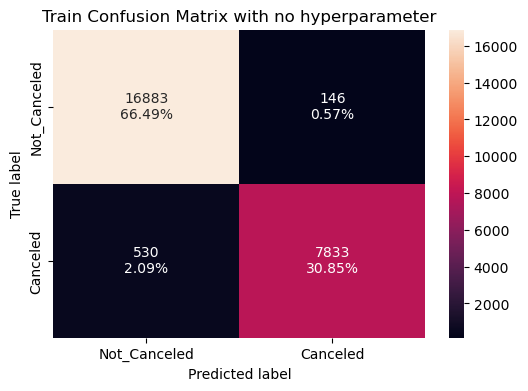

In [126]:
confusion_matrix_sklearn(
    model0, X_train5, y_train, title="Train Confusion Matrix with no hyperparameter"
)

In [128]:
# Train metric performance
print("Training performance:")
inn_train_perf = model_performance_classification_sklearn(model0, X_train5, y_train)
inn_train_perf

Training performance:


,Accuracy,Recall,Precision,F1
0,0.97338,0.93663,0.98170,0.95863


In [130]:
# dropping variables from test set as well which were dropped from training set
X_test = X_test[selected_features]

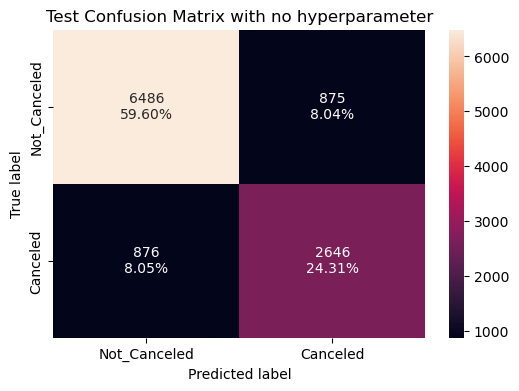

In [132]:
# building a confusion matrix with no hyperparameter for test set
confusion_matrix_sklearn(
    model0, X_test, y_test, title="Test Confusion Matrix with no hyperparameter"
)

In [134]:
print("Test performance:")
inn_test_perf = model_performance_classification_sklearn(model0, X_test, y_test)
inn_test_perf

Test performance:


,Accuracy,Recall,Precision,F1
0,0.83911,0.75128,0.75149,0.75138


### Decision Tree (with class_weights)

In [136]:
# build tree using just class_weight balance on train set

model1 = DecisionTreeClassifier(class_weight="balanced", random_state=1)
model1.fit(X_train5, y_train)

DecisionTreeClassifier(class_weight='balanced', random_state=1)

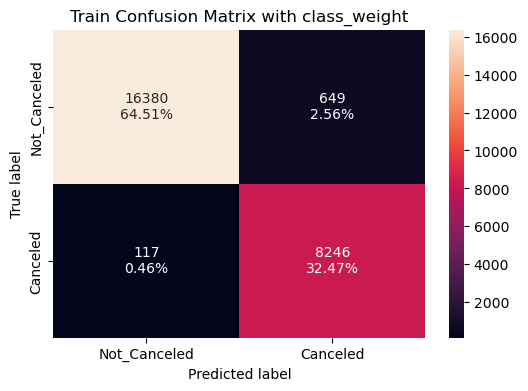

In [138]:
confusion_matrix_sklearn(
    model1, X_train5, y_train, title="Train Confusion Matrix with class_weight"
)

In [140]:
print("Class-Weight Training performance:")
inn_train_cw_perf = model_performance_classification_sklearn(model1, X_train5, y_train)
inn_train_cw_perf

Class-Weight Training performance:


,Accuracy,Recall,Precision,F1
0,0.96983,0.98601,0.92704,0.95561


- On Test set

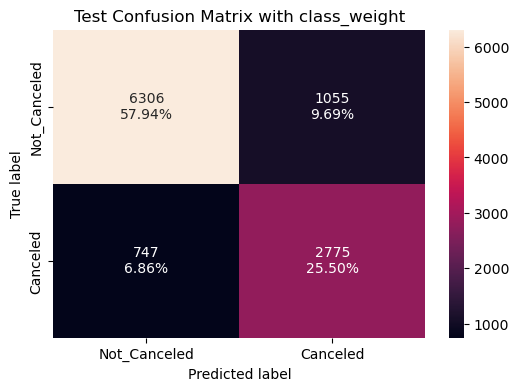

In [142]:
confusion_matrix_sklearn(
    model1, X_test, y_test, title="Test Confusion Matrix with class_weight"
)

In [144]:
print("Class-Weight Test performance:")
inn_test_cw_perf = model_performance_classification_sklearn(model1, X_test, y_test)
inn_test_cw_perf

Class-Weight Test performance:


,Accuracy,Recall,Precision,F1
0,0.83442,0.78790,0.72454,0.75490


Prepare the Decision tree

In [146]:
# create featured names for decision tree building
feature_names = list(X_train5.columns)
print(feature_names)

['no_of_children', 'no_of_weekend_nights', 'no_of_week_nights', 'type_of_meal_plan', 'required_car_parking_space', 'room_type_reserved', 'lead_time', 'market_segment_type', 'repeated_guest', 'no_of_previous_cancellations', 'no_of_special_requests', 'day_of_week_Monday', 'day_of_week_Saturday', 'day_of_week_Sunday', 'day_of_week_Thursday', 'day_of_week_Tuesday', 'day_of_week_Wednesday', 'season_Winter']


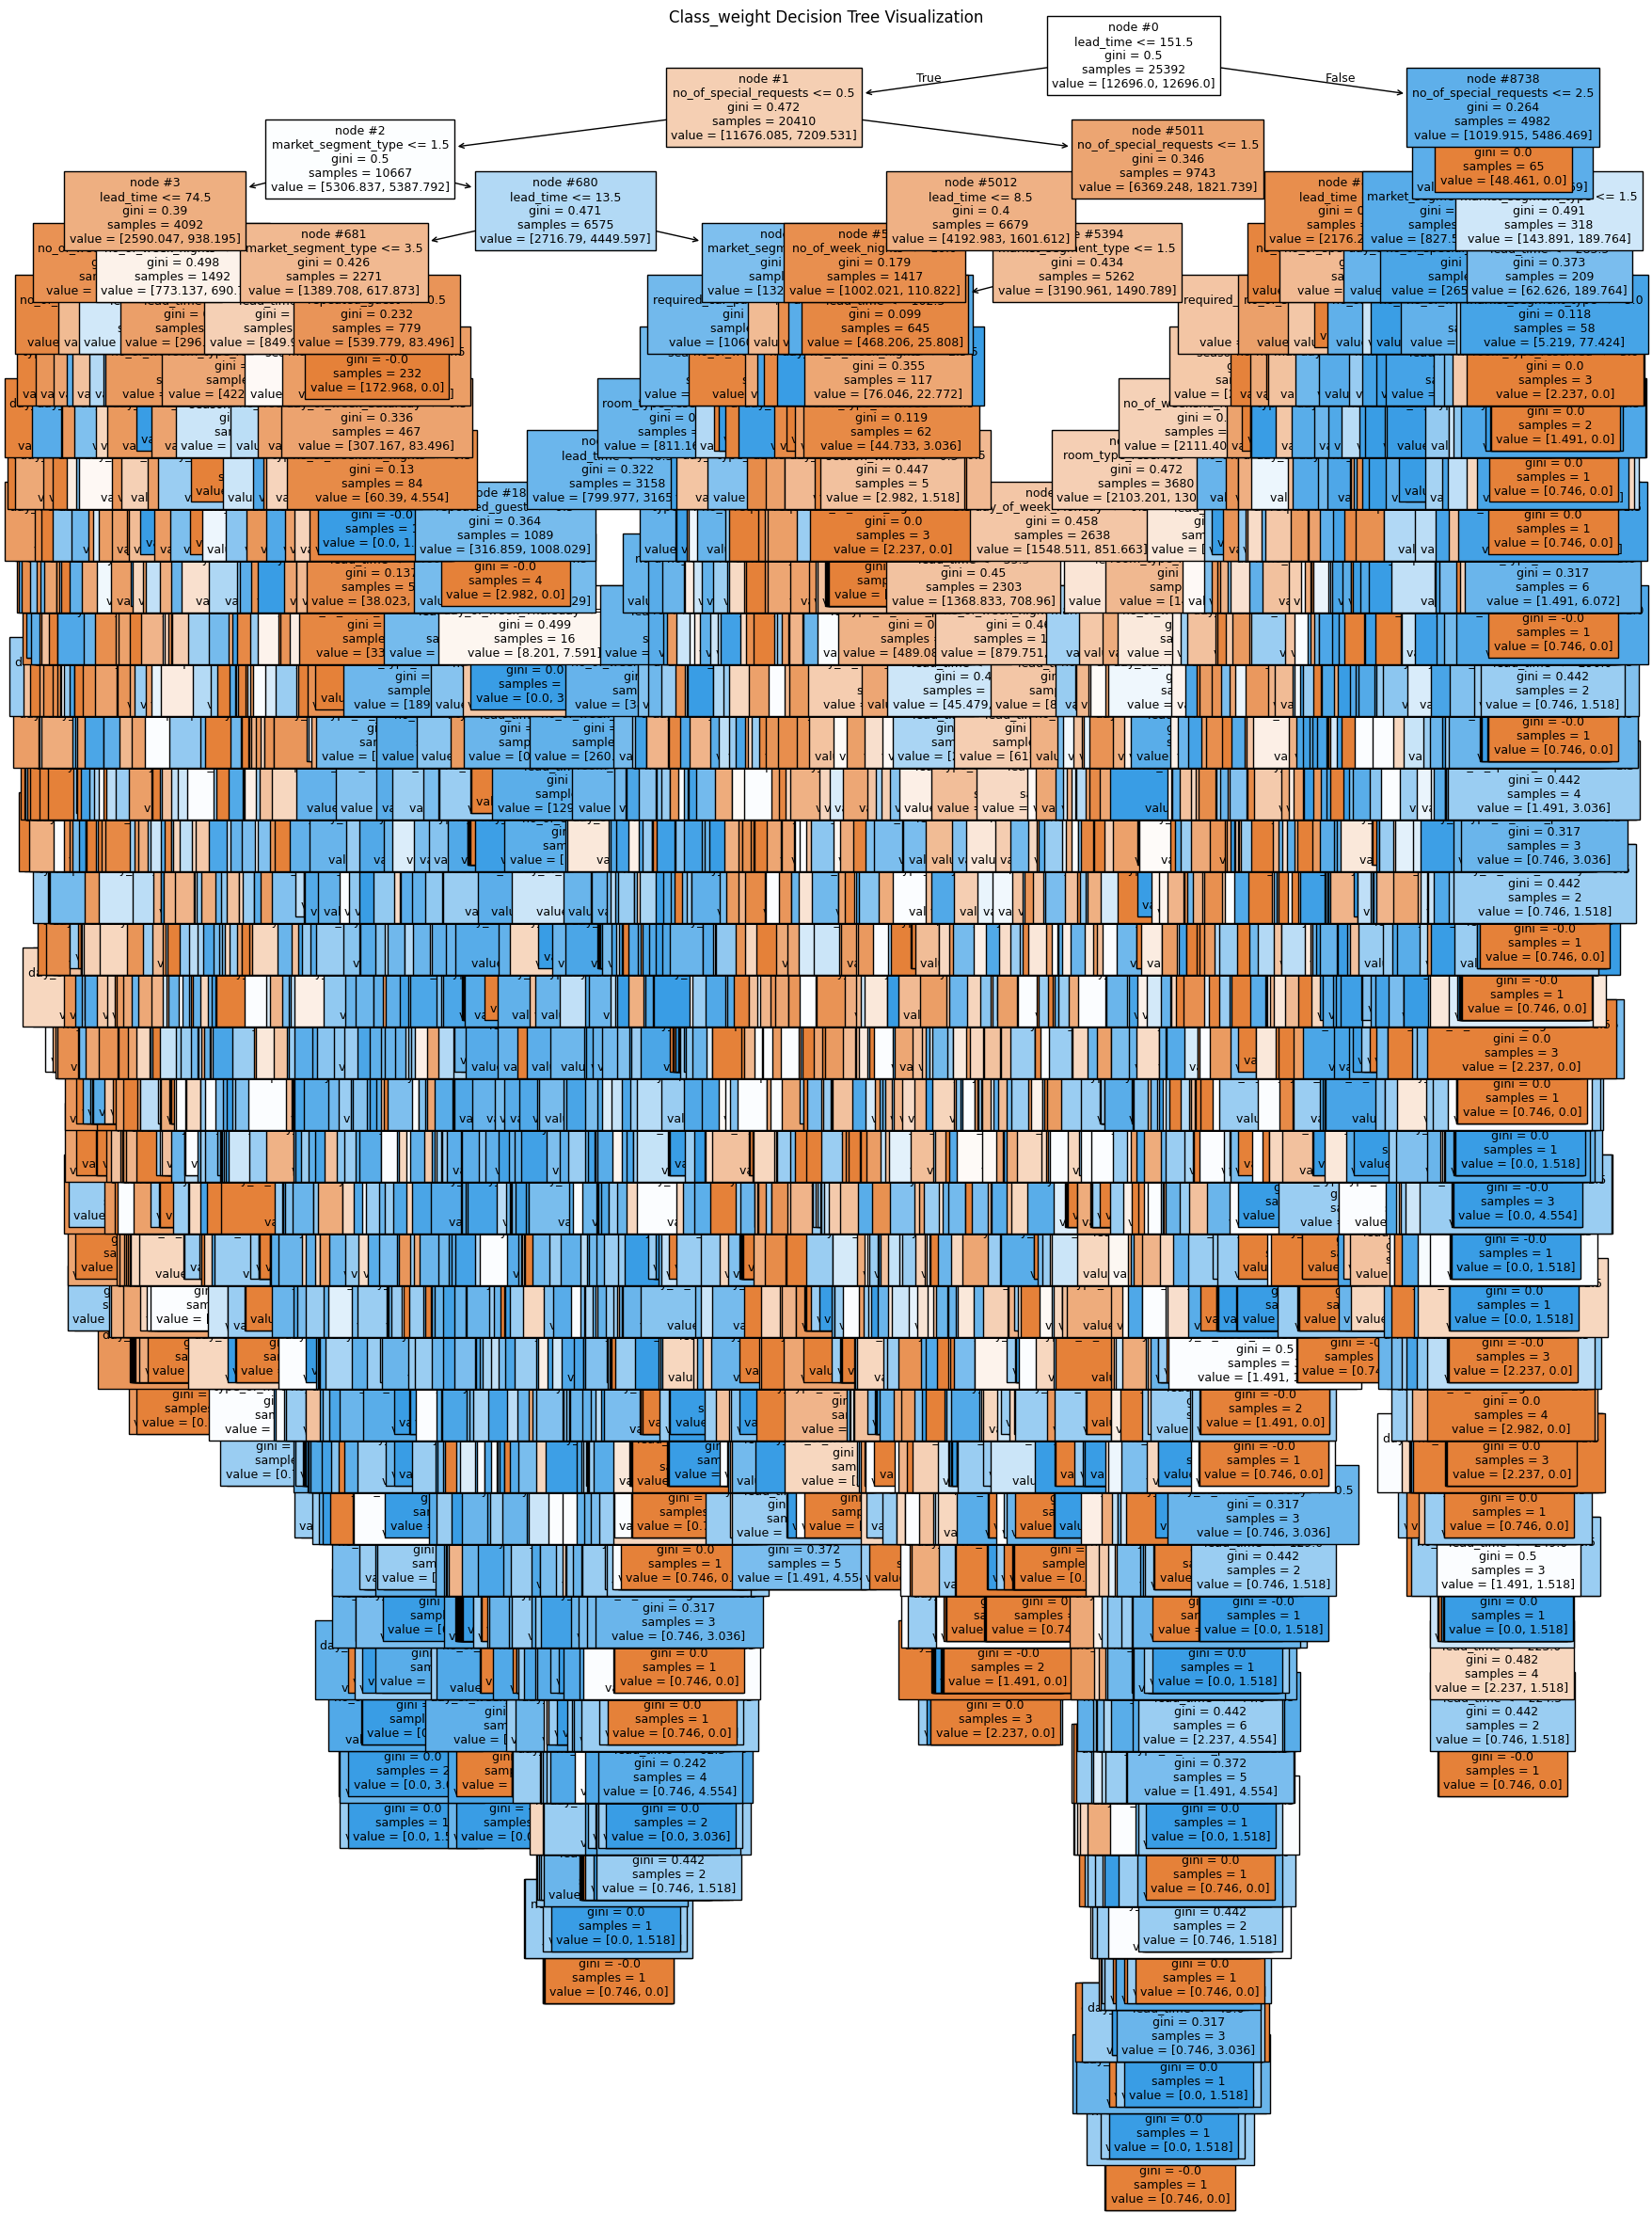

In [84]:
# plotting the tree
# estimator = estimator = DecisionTreeClassifier(random_state=1)
plt.figure(figsize=(20, 30))
out = tree.plot_tree(
    model1,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=True,
    class_names=None,
)
# below code will add arrows to the decision tree split if they are missing
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)
plt.title("Class_weight Decision Tree Visualization")
plt.show();

Because of the complexity of the tree, we have to apply pruning.

## Decision Tree Pre-Pruning

- We will use Grid search a tuning technique that attempts to compute the optimum values of hyperparameters for pre-pruning.

In [148]:
# Choose the type of classifier.
estimator = DecisionTreeClassifier(random_state=1)

# Grid of parameters to choose from
parameters = {
    "class_weight": [None, "balanced"],
    "max_depth": np.arange(2, 7, 2),
    "max_leaf_nodes": [50, 75, 150, 250],
    "min_samples_split": [10, 30, 50, 70],
}

# Type of scoring used to compare parameter combinations
acc_scorer = make_scorer(f1_score)

# Run the grid search
grid_obj = GridSearchCV(estimator, parameters, scoring=acc_scorer, cv=5)
grid_obj = grid_obj.fit(X_train, y_train)

# Set the clf to the best combination of parameters
estimator = grid_obj.best_estimator_

# Fit the best algorithm to the data.
estimator.fit(X_train5, y_train)

DecisionTreeClassifier(class_weight='balanced', max_depth=6, max_leaf_nodes=50,
                       min_samples_split=10, random_state=1)

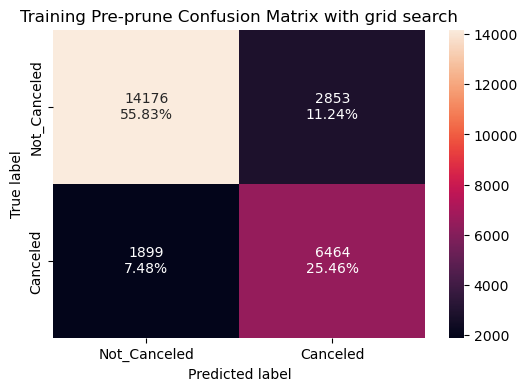

In [150]:
confusion_matrix_sklearn(
    estimator,
    X_train5,
    y_train,
    title="Training Pre-prune Confusion Matrix with grid search",
)

In [152]:
print("Pre-prune Training performance:")
inn_train_pre_perf = model_performance_classification_sklearn(estimator, X_train5, y_train)
inn_train_pre_perf

Pre-prune Training performance:


,Accuracy,Recall,Precision,F1
0,0.81285,0.77293,0.69379,0.73122


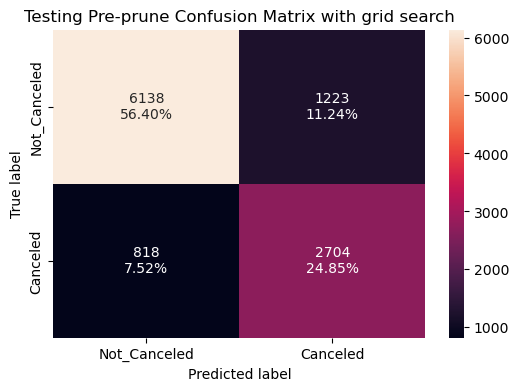

In [154]:
confusion_matrix_sklearn(
    estimator,
    X_test,
    y_test,
    title="Testing Pre-prune Confusion Matrix with grid search",
)

In [156]:
print("Pre-prune Test performance:")
inn_test_pre_perf = model_performance_classification_sklearn(estimator, X_test, y_test)
inn_test_pre_perf

Pre-prune Test performance:


,Accuracy,Recall,Precision,F1
0,0.81246,0.76775,0.68857,0.72600


* The model is now giving a generalized result since the f1 scores on both the train and test data are coming to be around 0.73 (much closer in comparison), which shows that the model can generalize well on unseen data
* Plotting the tree after pre-pruning

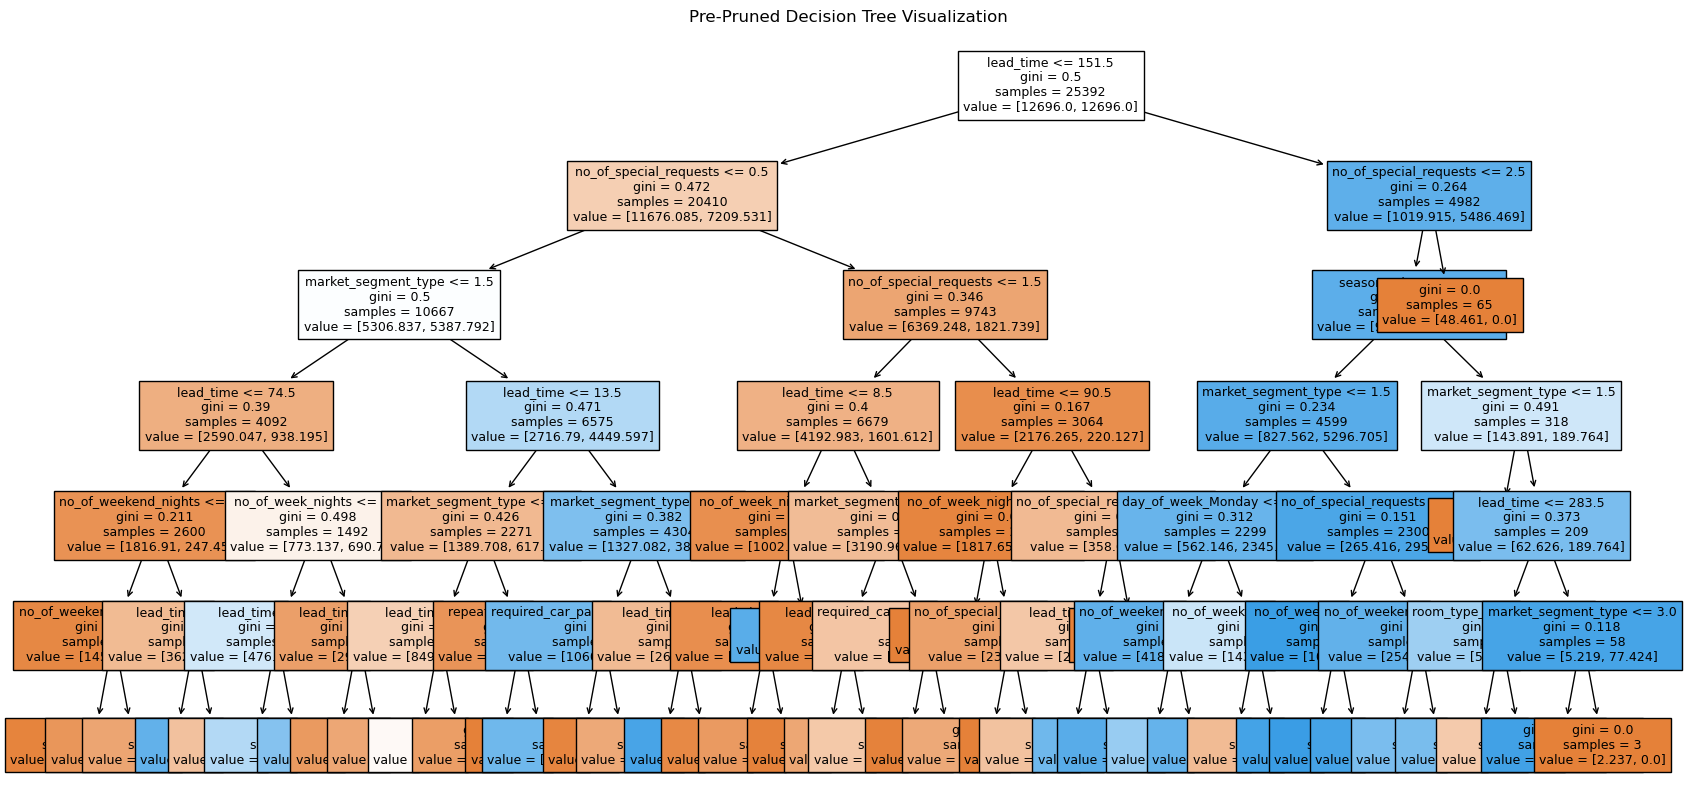

In [158]:
#Plotting the tree after pre-pruning

plt.figure(figsize=(20, 10))
out = tree.plot_tree(
    estimator,
    feature_names=feature_names,
    filled=True,
    fontsize=9,
    node_ids=False,
    class_names=None,
)
# below code will add arrows to the decision tree split if they are missing
for o in out:
    arrow = o.arrow_patch
    if arrow is not None:
        arrow.set_edgecolor("black")
        arrow.set_linewidth(1)
plt.title("Pre-Pruned Decision Tree Visualization")
plt.show();

In [160]:
# Text report showing the rules of a decision tree -
print(tree.export_text(estimator, feature_names=feature_names, show_weights=True))

|--- lead_time <= 151.50
|   |--- no_of_special_requests <= 0.50
|   |   |--- market_segment_type <= 1.50
|   |   |   |--- lead_time <= 74.50
|   |   |   |   |--- no_of_weekend_nights <= 1.50
|   |   |   |   |   |--- no_of_weekend_nights <= 0.50
|   |   |   |   |   |   |--- weights: [1104.91, 24.29] class: 0.0
|   |   |   |   |   |--- no_of_weekend_nights >  0.50
|   |   |   |   |   |   |--- weights: [349.66, 57.69] class: 0.0
|   |   |   |   |--- no_of_weekend_nights >  1.50
|   |   |   |   |   |--- lead_time <= 68.50
|   |   |   |   |   |   |--- weights: [348.92, 100.20] class: 0.0
|   |   |   |   |   |--- lead_time >  68.50
|   |   |   |   |   |   |--- weights: [13.42, 65.28] class: 1.0
|   |   |   |--- lead_time >  74.50
|   |   |   |   |--- no_of_week_nights <= 2.50
|   |   |   |   |   |--- lead_time <= 90.50
|   |   |   |   |   |   |--- weights: [137.18, 69.83] class: 0.0
|   |   |   |   |   |--- lead_time >  90.50
|   |   |   |   |   |   |--- weights: [339.23, 549.56] class: 1.0

**Observations from the pre-pruned tree:**

Using the above extracted decision rules we can make interpretations from the decision tree model like:

* If the lead time is less than or equal to 151.50, the no_of_special_requests is less than or equal to 0.5, then the booking is most likey to be canceled.

In [165]:
# Quantify, retrieve and show how important each feature was in building the decision tree model.
importances = estimator.feature_importances_
importances

array([0.        , 0.01982708, 0.02580498, 0.        , 0.01626011,
       0.00168247, 0.56502146, 0.17735102, 0.00153341, 0.        ,
       0.17534023, 0.00727619, 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.00990305])

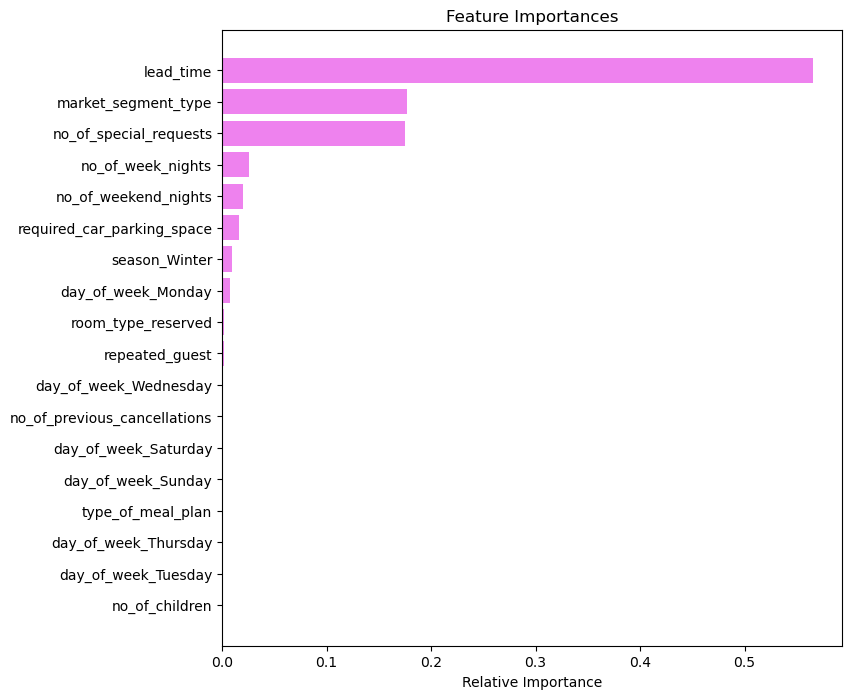

In [167]:
# Visualizing the importance of the features in a horizontal bar plot

importances = estimator.feature_importances_
indices = np.argsort(importances)

plt.figure(figsize=(8, 8))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

In the pre tuned decision tree also, lead time, market segment type, and number of special requests are the most important features.
However, we observed a huge improvement in the model's performance, as the test set for the recall metrics matches the train set in all the metrics.
- It was observed that number of weekday and weekend nights along with required_parking space and season of winter also plays some role in the decision tree


Decision Tree Model with Post-Pruning

In [169]:
# Obtain ccp_alphas and impurities

clf = DecisionTreeClassifier(random_state=1, class_weight="balanced")
path = clf.cost_complexity_pruning_path(X_train5, y_train)
ccp_alphas, impurities = abs(path.ccp_alphas), path.impurities

In [171]:
# train a decision tree using the effective alphas.
clfs = []
for ccp_alpha in ccp_alphas:
    clf = DecisionTreeClassifier(
        random_state=1, ccp_alpha=ccp_alpha, class_weight="balanced"
    )
    clf.fit(X_train5, y_train)
    clfs.append(clf)
print(
    "Number of nodes in the last tree is: {} with ccp_alpha: {}".format(
        clfs[-1].tree_.node_count, ccp_alphas[-1]
    )
)

Number of nodes in the last tree is: 1 with ccp_alpha: 0.08117914389137226


In [173]:
# Evaluate train recall performance on the pruned Decision Tree model
f1_train = []
for clf in clfs:
    pred_train = clf.predict(X_train5)
    values_train = f1_score(y_train, pred_train)  # Use F1-score instead of recall
    f1_train.append(values_train)

In [175]:
# Evaluate test recall performance on the pruned Decision Tree model
f1_test = []
for clf in clfs:
    pred_test = clf.predict(X_test)
    values_test = f1_score(y_test, pred_test)  # Use F1-score instead of recall
    f1_test.append(values_test)

In [177]:
# Obtain the test and train scores
train_scores = [clf.score(X_train5, y_train) for clf in clfs]
test_scores = [clf.score(X_test, y_test) for clf in clfs]

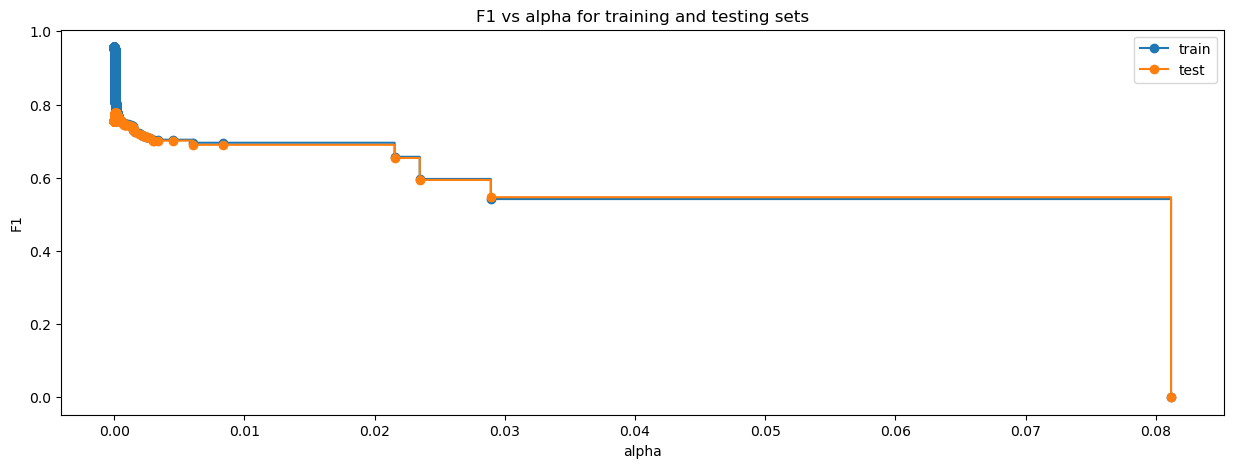

In [179]:
# Recall vs alpha for training and testing sets
fig, ax = plt.subplots(figsize=(15, 5))
ax.set_xlabel("alpha")
ax.set_ylabel("F1")
ax.set_title("F1 vs alpha for training and testing sets")
ax.plot(
    ccp_alphas, f1_train, marker="o", label="train", drawstyle="steps-post",
)
ax.plot(ccp_alphas, f1_test, marker="o", label="test", drawstyle="steps-post")
ax.legend()
plt.show();

In [181]:
# creating the model where we get highest train and test recall
index_best_model = np.argmax(f1_test)
best_model = clfs[index_best_model]
print(best_model)

DecisionTreeClassifier(ccp_alpha=9.443475847477947e-05, class_weight='balanced',
                       random_state=1)


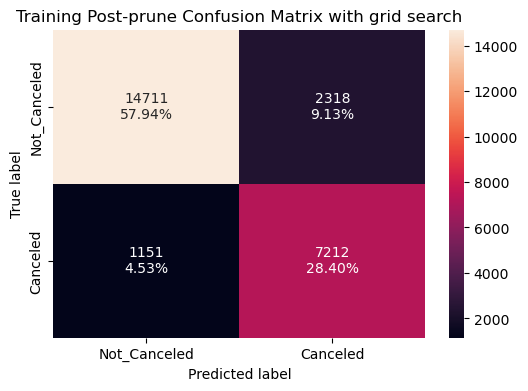

In [183]:
confusion_matrix_sklearn(
    best_model,
    X_train5,
    y_train,
    title="Training Post-prune Confusion Matrix with grid search",
)

In [185]:
print("Post-prune Training performance:")
inn_train_post_perf = model_performance_classification_sklearn(
    best_model, X_train5, y_train
)
inn_train_post_perf

Post-prune Training performance:


,Accuracy,Recall,Precision,F1
0,0.86338,0.86237,0.75677,0.80613


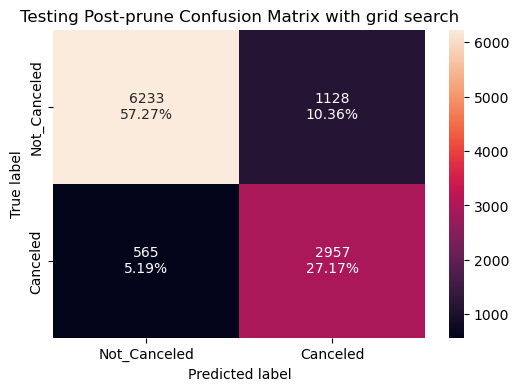

In [187]:
confusion_matrix_sklearn(
    best_model,
    X_test,
    y_test,
    title="Testing Post-prune Confusion Matrix with grid search",
)

In [189]:
print("Post-prune Test performance:")
inn_test_post_perf = model_performance_classification_sklearn(
    best_model, X_test, y_test
)
inn_test_post_perf

Post-prune Test performance:


,Accuracy,Recall,Precision,F1
0,0.84444,0.83958,0.72387,0.77744


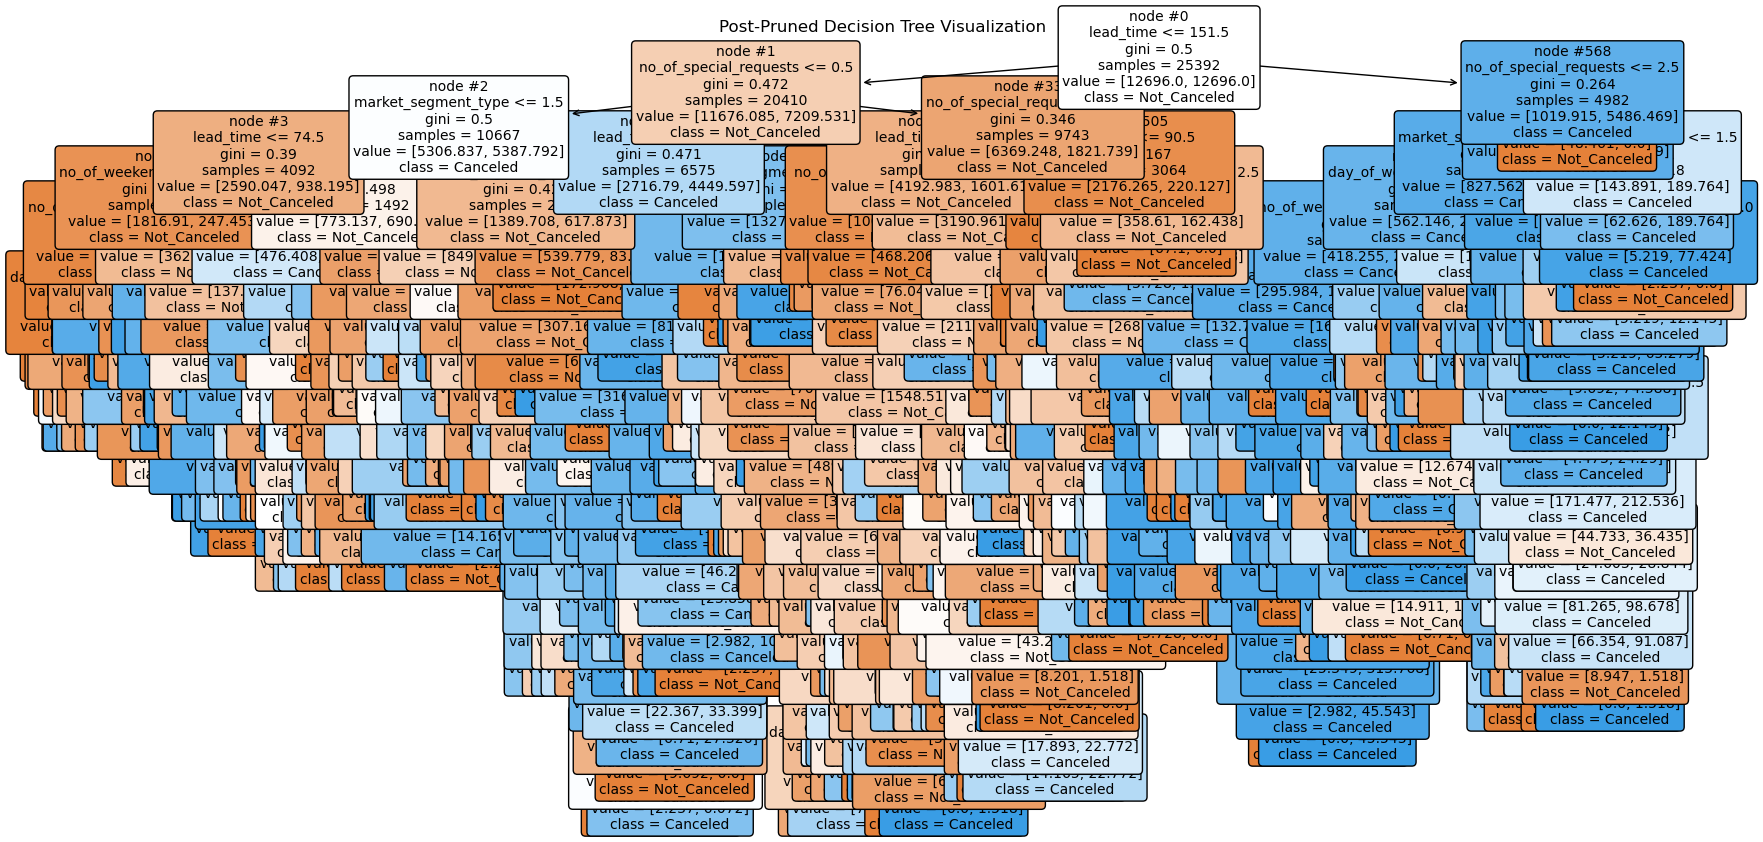

In [191]:
plt.figure(figsize=(20, 10))  # Adjust figure size for better readability
plot_tree(
    best_model,
    filled=True,
    feature_names=feature_names,
    fontsize=10,
    node_ids=True,
    class_names=["Not_Canceled", "Canceled"],
    rounded=True,
)
plt.title("Post-Pruned Decision Tree Visualization")
plt.show();

In [193]:
# Text report showing the rules of a decision tree -

print(tree.export_text(best_model, feature_names=feature_names, show_weights=True))

|--- lead_time <= 151.50
|   |--- no_of_special_requests <= 0.50
|   |   |--- market_segment_type <= 1.50
|   |   |   |--- lead_time <= 74.50
|   |   |   |   |--- no_of_weekend_nights <= 1.50
|   |   |   |   |   |--- no_of_weekend_nights <= 0.50
|   |   |   |   |   |   |--- type_of_meal_plan <= 2.50
|   |   |   |   |   |   |   |--- day_of_week_Saturday <= 0.50
|   |   |   |   |   |   |   |   |--- weights: [849.93, 1.52] class: 0.0
|   |   |   |   |   |   |   |--- day_of_week_Saturday >  0.50
|   |   |   |   |   |   |   |   |--- type_of_meal_plan <= 1.50
|   |   |   |   |   |   |   |   |   |--- weights: [234.85, 0.00] class: 0.0
|   |   |   |   |   |   |   |   |--- type_of_meal_plan >  1.50
|   |   |   |   |   |   |   |   |   |--- lead_time <= 33.50
|   |   |   |   |   |   |   |   |   |   |--- weights: [17.15, 0.00] class: 0.0
|   |   |   |   |   |   |   |   |   |--- lead_time >  33.50
|   |   |   |   |   |   |   |   |   |   |--- weights: [2.98, 21.25] class: 1.0
|   |   |   |   |   |  

In [195]:
# Quantify, retrieve and show how important each feature was in building the decision tree model.
importances = best_model.feature_importances_
indices = np.argsort(importances)

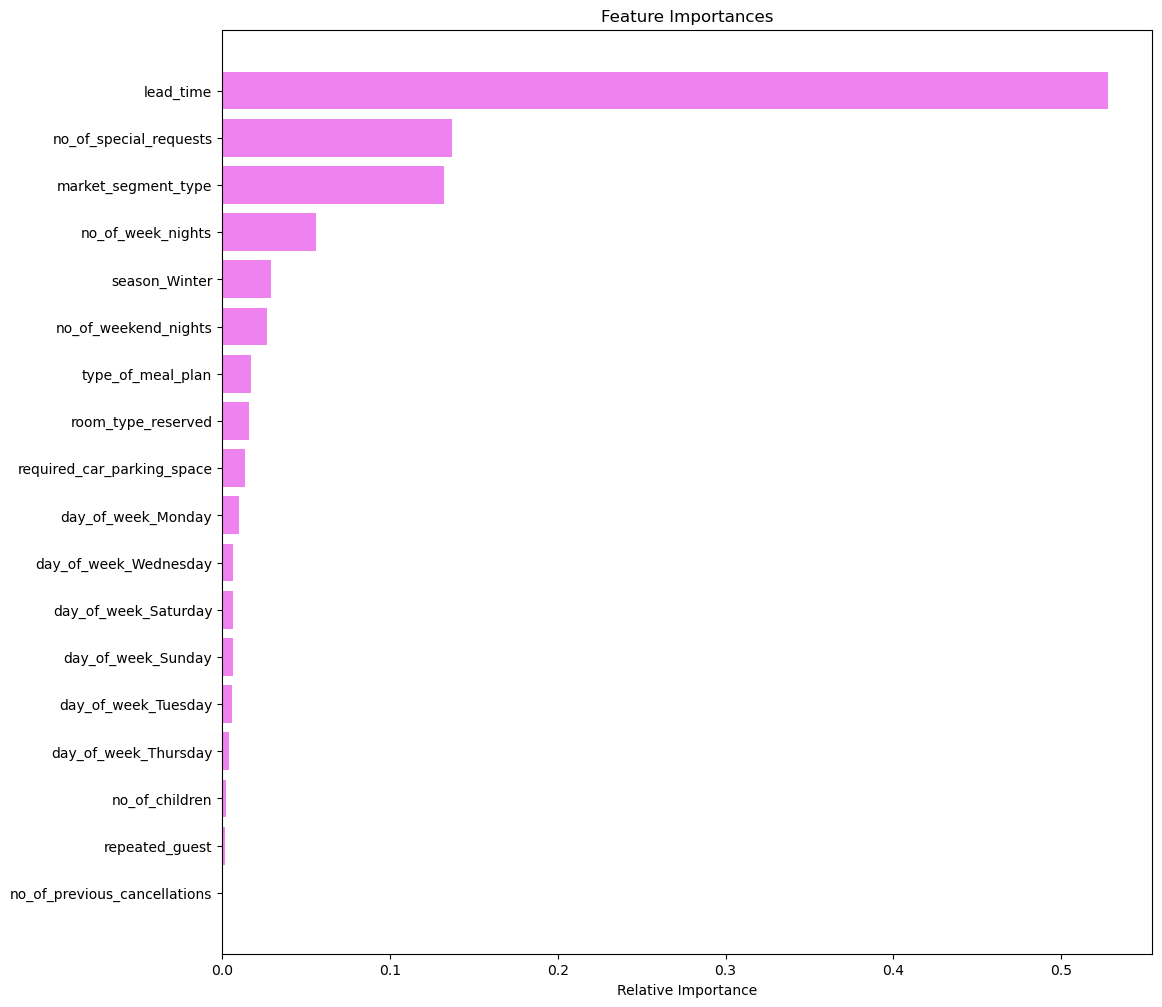

In [197]:
# Visualizing the importance of the features in a horizontal bar plot

plt.figure(figsize=(12, 12))
plt.title("Feature Importances")
plt.barh(range(len(indices)), importances[indices], color="violet", align="center")
plt.yticks(range(len(indices)), [feature_names[i] for i in indices])
plt.xlabel("Relative Importance")
plt.show()

## Model Performance Comparison and Conclusions

In [199]:
# training performance comparison for all the different decision tree models

models_train_comp_df = pd.concat(
    [
        inn_train_perf.T,
        inn_train_cw_perf.T,
        inn_train_pre_perf.T,
        inn_train_post_perf.T,
    ],
    axis=1,
)
models_train_comp_df.columns = [
    "Inn Tree without class_weight",
    "Inn Tree with class_weight",
    "Inn Tree (Pre-Pruning)",
    "Inn Tree (Post-Pruning)",
]
print("Training performance comparison:")
models_train_comp_df

Training performance comparison:


,Inn Tree without class_weight,Inn Tree with class_weight,Inn Tree (Pre-Pruning),Inn Tree (Post-Pruning)
Accuracy,0.97338,0.96983,0.81285,0.86338
Recall,0.93663,0.98601,0.77293,0.86237
Precision,0.98170,0.92704,0.69379,0.75677
F1,0.95863,0.95561,0.73122,0.80613


In [201]:
# testing performance comparison for all the different decision tree models

models_test_comp_df = pd.concat(
    [
        inn_test_perf.T,
        inn_test_cw_perf.T,
        inn_test_pre_perf.T,
        inn_test_post_perf.T,
    ],
    axis=1,
)
models_test_comp_df.columns = [
    "Inn Tree without class_weight",
    "Inn Tree with class_weight",
    "Inn Tree (Pre-Pruning)",
    "Inn Tree (Post-Pruning)",
]
print("Test set performance comparison:")
models_test_comp_df

Test set performance comparison:


,Inn Tree without class_weight,Inn Tree with class_weight,Inn Tree (Pre-Pruning),Inn Tree (Post-Pruning)
Accuracy,0.83911,0.83442,0.81246,0.84444
Recall,0.75128,0.78790,0.76775,0.83958
Precision,0.75149,0.72454,0.68857,0.72387
F1,0.75138,0.75490,0.72600,0.77744


* Decision tree models with pre-pruning and post-pruning both are giving equally high F1 scores on both training and test sets.
* However, we will choose the post-pruned tree as the best model since it is also slightly higher in other metric (Accuracy, Precision and recall) scores on the train and test sets than the post-pruned tree.

## Conclusions
- For reducing both False Negatives and False Positives, the model built can predict if a hotel booking will be cancelled or not and correctly identify 77.7% of the potential booking cancellations.

- Lead Time, Number of Special Requests, and Market Segment type are the most important variables in predicting whether a hotel booking will cancel or not cancel.

## Actionable Insights and Recommendations

- From the Decision Tree, it was observed that if Lead time is less than or equal to 151.5 and the Number of special requests is less than or equal to 0.5, then the booking is most likely to be canceled.
- Other notable factors that affect the booking status include the market segment type, winter season (bad weather can lead to flight delay and or possible cancelations), and parking space requirements
  - The Hotel Boards should show more interest in these factors and put more amenities in place to meet customers' requests/needs.
  - For customers with fewer special requests and higher cancellation rates, the board can introduce incentives to retain them.
- Since lead time significantly impacts the classification, the board should analyze booking patterns and adjust pricing or availability strategies accordingly. For example, offering discounts for bookings made far in advance (>151.5 days) may encourage more conversions and reduce the chances of cancelation.